In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy as sp
import seaborn as sns

settlement_raw = pd.read_csv('/content/drive/MyDrive/masta_of_disasta/TEKST/tekst_nowy/OSADA_SKORUPY_NEW.csv', encoding='cp1250')
settlement_mass_raw = pd.read_csv('/content/drive/MyDrive/masta_of_disasta/TEKST/tekst_nowy/osada_masa.csv', encoding='cp1250')
cemetery_raw = pd.read_csv('/content/drive/MyDrive/masta_of_disasta/TEKST/tekst_nowy/CMENT_NEW.csv', encoding='cp1250')

settlement_mass = settlement_mass_raw.groupby('Grupa').agg({'Masa_[g]':pd.Series.sum})
settlement_sherds = settlement_raw['Grupa techn.'].value_counts()

for pos in cemetery_raw.index.to_list():
  try:
    cemetery_raw.at[pos, 'Masa [g]'] = int(cemetery_raw.at[pos, 'Masa [g]'])
  except ValueError:
    cemetery_raw.at[pos, 'Masa [g]'] = 0

cemetery_mass = cemetery_raw.groupby('Grupa techn.').agg({'Masa [g]':pd.Series.sum})
cemetery_sherds = cemetery_raw.groupby('Grupa techn.').agg({'Ilość skorup': pd.Series.sum})

cemetery_no_plaster = cemetery_raw
substring1 = 'GIPS'
substring2 = 'brak możliwości zważenia'
for row in cemetery_no_plaster.index.to_list():
  if substring1 in cemetery_no_plaster.at[row, 'Uwagi'] or substring2 in cemetery_no_plaster.at[row, 'Uwagi']:
    cemetery_no_plaster.drop(row, inplace=True)

In [3]:
# settlement_mass
# settlement_sherds
# cemetery_mass
# cemetery_sherds

In [4]:
def odds_ratio_new(table: pd.DataFrame) -> pd.DataFrame:
  table = table.astype('int64')
  # groups = table.index.to_list()
  # p = []
  # for i in range(2):
  #   p.append(np.array([table[table.columns[i]].loc[item]/(table[table.columns[i]].sum() - table[table.columns[i]].loc[item]) for item in table.index]))
  # for i in range(len(table.index)):
  #   print(table.loc[table.index[i]].sum())
  # for item in table:
  #   sum = table[item].sum()
    # for key in groups:
    #   table.at[key, item] = table.at[key, item] / sum
  # odds0 = p[0]/p[1]
  # odds1 = p[1]/p[0]

  tabs = []
  for item in (table.index):
    col0 = pd.Series([table[table.columns[0]].loc[item], table[table.columns[1]].loc[item]])
    col1 = pd.Series([table[table.columns[0]].sum() - table[table.columns[0]].loc[item], table[table.columns[1]].sum() - table[table.columns[1]].loc[item]])
    tab = pd.concat([col0, col1], axis=1)
    tabs.append(tab)

  objects = [sp.stats.contingency.odds_ratio(item, kind='sample') for item in tabs]
  odds = [item.statistic for item in objects]
  ci = [item.confidence_interval(confidence_level=0.95) for item in objects]
  # print([item.statistic for item in objects])
  # print([item.confidence_interval(confidence_level=0.95) for item in objects])


  table.insert(loc=2, column='odds_ratio', value=odds)
  table.insert(loc=3, column='confidence_interval', value=ci)

  return table


def odds_ratio(table: pd.DataFrame) -> pd.DataFrame:
  table = table.astype('float')
  p = []
  for i in range(2):
    p.append(np.array([table[table.columns[i]].loc[item]/(table[table.columns[i]].sum() - table[table.columns[i]].loc[item]) for item in table.index]))
  odds0 = p[0]/p[1]
  odds1 = p[1]/p[0]
  for i in range(len(p)):
   table.insert(loc=i+2, column=f'proportion{i}', value=p[i])
  table.insert(loc=4, column=f'odds_ratio{0}', value=odds0)
  table.insert(loc=5, column=f'odds_ratio{1}', value=odds1)
  return table


def rel_risk(table: pd.DataFrame) -> pd.DataFrame:
  table = table.astype('float')
  # groups = table.index.to_list()
  p = []
  for i in range(2):
    p.append(np.array([table[table.columns[i]].loc[item]/table[table.columns[i]].sum() for item in table.index]))
  # for i in range(len(table.index)):
  #   print(table.loc[table.index[i]].sum())
  # for item in table:
  #   sum = table[item].sum()
    # for key in groups:
    #   table.at[key, item] = table.at[key, item] / sum
  odds0 = p[0]/p[1]
  odds1 = p[1]/p[0]
  for i in range(len(p)):
   table.insert(loc=i+2, column=f'proportion{i}', value=p[i])
  table.insert(loc=4, column=f'odds_ratio{0}', value=odds0)
  table.insert(loc=5, column=f'odds_ratio{1}', value=odds1)
  return table


def decimal(n):
  return ("%.2f" % n).rstrip('0').rstrip('.')


def percentage(df: pd.DataFrame) -> pd.DataFrame:
  data = {}
  for col in df.columns.to_list():
    sum = df[col].sum()
    l = [df[col].loc[row]/sum*100 for row in df.index.to_list()]
    data[col] = l
    # for row in df.index.to_list():
    #   df.at[row, col] = df.at[row, col] / sum * 100
  new = pd.DataFrame(data=data, index=df.index.to_list())
  return new

In [5]:
# perform tests for proportions:
#. 1. Chi squared with 3c
#. 2. C.s. without 3c
#. 3. C.s. with groups 2 and 3 conjoined (with and without 3c)
#. 4. C.s. for mass (without the plaster from the cemetery) all as above

# charts:
# a bar chart: mass and sherds number for both settlement and cemetery (percentage)
# as above, with tech. groups conjoined

#just to be sure: chi squared tests for both cemetery and settlement comparing mass and sherds number
#(exclude plastered pots in cemetery)

# **chi squared with 3c**

## sherds

In [6]:
cem_dict = {}
for row in cemetery_sherds.index.to_list():
  cem_dict[str(row)] = cemetery_sherds.at[row, 'Ilość skorup']
# s_dict
cemetery_sherds_series = pd.Series(data=cem_dict, index=cemetery_sherds.index.to_list())
# cemetery_sherds_series

cemetery_null = pd.Series([0, 0], index=['2b', '3c'])
cemetery_full_series = pd.concat([cemetery_sherds_series, cemetery_null])
# cemetery_full_series
cemetery_full_series = cemetery_full_series.reindex(index=['1', '2a', '2b', '3a', '3b', '3c', '4'])
cemetery_full_series

,0
1,703
2a,583
2b,0
3a,16586
3b,7617
3c,0
4,116


In [7]:
set_dict = {}
for row in settlement_sherds.index.to_list():
  set_dict[str(row)] = settlement_sherds.at[row]
# s_dict
settlement_sherds_series = pd.Series(data=set_dict, index=settlement_sherds.index.to_list())
# type(settlement_sherds_series)
settlement_full_series = settlement_sherds_series.reindex(index=['1', '2a', '2b', '3a', '3b', '3c', '4'])
settlement_full_series

,0
1,26
2a,97
2b,68
3a,414
3b,705
3c,771
4,12


In [8]:
# data = [cemetery_full_series, settlement_full_series]
# test1 = sp.stats.chi2_contingency(data)
# test1.pvalue

In [9]:
joined = pd.concat([cemetery_full_series, settlement_full_series], axis=1)
joined.rename(columns={0:"Trzęsówka 1\n(cmentarzysko)", 1:"Trzęsówka 2\n(osada)"}, inplace=True)
# print(joined)

# print(joined.index)
# for item in joined.index:
#     print(joined.loc[item])


# done this at first:
# test_data = np.array([[joined.at[row, pos] for pos in joined.columns] for row in joined.index.tolist()])
# but then discovered:
# test_data = percentage(joined).to_numpy()
# test_data


# test2 = sp.stats.chi2_contingency(test_data)

# THIS ONE:
# prop = odds_ratio(joined)
# prop
prop = odds_ratio_new(joined)
prop

# decimal(test2.pvalue)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:155: RuntimeWarning: divide by zero encountered in log
  log_or = np.log(oddsratio)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:156: RuntimeWarning: divide by zero encountered in divide
  se = np.sqrt((1/table).sum())
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:169: RuntimeWarning: invalid value encountered in scalar add
  loghigh = log_or + z*se


,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
1,703,26,2.244338,"(1.5134984126770357, 3.3280855382054306)"
2a,583,97,0.479441,"(0.3848744291110506, 0.5972437554895533)"
2b,0,68,0.000000,"(0.0, nan)"
3a,16586,414,7.458193,"(6.677537750311737, 8.330113261035532)"
3b,7617,705,0.833684,"(0.758492168496414, 0.9163296736825678)"
3c,0,771,0.000000,"(0.0, nan)"
4,116,12,0.789216,"(0.4348603971290891, 1.4323270508199357)"


In [10]:
joined2 = pd.concat([cemetery_full_series, settlement_full_series], axis=1)
joined2.rename(columns={0:"Trzęsówka 1\n(cmentarzysko)", 1:"Trzęsówka 2\n(osada)"}, inplace=True)

prop2 = odds_ratio_new(joined2)
prop2

/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:155: RuntimeWarning: divide by zero encountered in log
  log_or = np.log(oddsratio)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:156: RuntimeWarning: divide by zero encountered in divide
  se = np.sqrt((1/table).sum())
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:169: RuntimeWarning: invalid value encountered in scalar add
  loghigh = log_or + z*se


,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
1,703,26,2.244338,"(1.5134984126770357, 3.3280855382054306)"
2a,583,97,0.479441,"(0.3848744291110506, 0.5972437554895533)"
2b,0,68,0.000000,"(0.0, nan)"
3a,16586,414,7.458193,"(6.677537750311737, 8.330113261035532)"
3b,7617,705,0.833684,"(0.758492168496414, 0.9163296736825678)"
3c,0,771,0.000000,"(0.0, nan)"
4,116,12,0.789216,"(0.4348603971290891, 1.4323270508199357)"


In [11]:
# pivot_dict = {}
# for row in joined.index.to_list():
#   new = [joined.at[row, col] for col in joined.columns.to_list()]
#   pivot_dict[row] = new
# # pivot_dict

# joined_pivot = pd.DataFrame(data=pivot_dict, index=joined.columns.to_list())
# joined_pivot

# test3 = sp.stats.chi2_contingency(joined_pivot)
# test3.pvalue

# print(f'{test1.statistic}\n{test2.statistic}\n{test3.statistic}')

# the tests' stats are exactly the same in both cases

## mass

In [12]:
cemetery_mass_no_plaster = cemetery_no_plaster.groupby('Grupa techn.').agg({'Masa [g]':pd.Series.sum})
# cemetery_mass_no_plaster

cem_mass_dict = {}
for row in cemetery_mass_no_plaster.index.to_list():
  cem_mass_dict[str(row)] = cemetery_mass_no_plaster.at[row, 'Masa [g]']
# cem_mass_dict
cemetery_no_plaster_series = pd.Series(data=cem_mass_dict, index=cemetery_mass_no_plaster.index.to_list())
# cemetery_no_plaster_series

cemetery_null = pd.Series([0, 0], index=['2b', '3c'])
cemetery_full_no_plaster = pd.concat([cemetery_no_plaster_series, cemetery_null])
# cemetery_full_no_plaster

cemetery_full_no_plaster = cemetery_full_no_plaster.reindex(index=['1', '2a', '2b', '3a', '3b', '3c', '4'])
# cemetery_full_no_plaster

In [13]:
# for row in cemetery_full_no_plaster.index.to_list():
#   cemetery_full_no_plaster.at[row] = float(cemetery_full_no_plaster.at[row])

# cemetery_full_no_plaster

# WHY THE HECK DOESN'T IT WORK???

In [14]:
set_mass_dict = {}
for row in settlement_mass.index.to_list():
  set_mass_dict[str(row).lower()] = settlement_mass.at[row, 'Masa_[g]']
# set_mass_dict
settlement_mass_series = pd.Series(data=set_mass_dict, index=[item.lower() for item in settlement_mass.index.to_list()])
# settlement_mass_series

settlement_mass_series.drop(index='?', inplace=True)
# settlement_mass_series

In [15]:
joined_mass = pd.concat([cemetery_full_no_plaster, settlement_mass_series], axis=1)
joined_mass.rename(columns={0:"Trzęsówka 1\n(cmentarzysko)", 1:"Trzęsówka 2\n(osada)"}, inplace=True)
# joined_mass
# joined_mass.to_numpy()
# print(f'{percentage(joined_mass)}\n')
# mass_test = sp.stats.chi2_contingency(percentage(joined_mass).to_numpy())
# decimal(mass_test.pvalue)
prop_m = odds_ratio_new(joined_mass)
prop_m

/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:155: RuntimeWarning: divide by zero encountered in log
  log_or = np.log(oddsratio)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:156: RuntimeWarning: divide by zero encountered in divide
  se = np.sqrt((1/table).sum())
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:169: RuntimeWarning: invalid value encountered in scalar add
  loghigh = log_or + z*se


,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
1,15182,396,2.535569,"(2.2935951311012888, 2.8030715649610904)"
2a,16228,1743,0.595368,"(0.5660487335887582, 0.6262057326439143)"
2b,0,1223,0.000000,"(0.0, nan)"
3a,405362,7678,8.523058,"(8.308184591868761, 8.743487648881661)"
3b,161085,12944,0.740821,"(0.7248254595249672, 0.7571704601814819)"
3c,0,14865,0.000000,"(0.0, nan)"
4,1873,207,0.587963,"(0.5091487342257421, 0.6789772873384342)"


# **chi squared without 3c**



## sherds

In [16]:
joined_no3c = joined.drop(index='3c')
# joined_no3c
# print(f'{percentage(joined_no3c)}\n')
# test_no3c = sp.stats.chi2_contingency(percentage(joined_no3c).to_numpy())
# decimal(test_no3c.pvalue)
prop_no3c = odds_ratio_new(joined_no3c)
prop_no3c

/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:155: RuntimeWarning: divide by zero encountered in log
  log_or = np.log(oddsratio)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:156: RuntimeWarning: divide by zero encountered in divide
  se = np.sqrt((1/table).sum())
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:169: RuntimeWarning: invalid value encountered in scalar add
  loghigh = log_or + z*se


,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
1,703,26,1.407190,"(0.9476287112573734, 2.0896198690848995)"
2a,583,97,0.294246,"(0.23556177503324077, 0.36755045157848637)"
2b,0,68,0.000000,"(0.0, nan)"
3a,16586,414,4.033377,"(3.580771415536712, 4.543190683093285)"
3b,7617,705,0.370593,"(0.331550892377327, 0.4142323821006485)"
4,116,12,0.496816,"(0.27349761909915116, 0.902478642775922)"


## mass

In [17]:
joined_mass_no3c = joined_mass.drop(index='3c')
# joined_mass_no3c
# print(f'{percentage(joined_mass_no3c)}\n')
# test_no3c_mass = sp.stats.chi2_contingency(percentage(joined_mass_no3c).to_numpy())
# decimal(test_no3c_mass.pvalue)
prop_m_no3c = odds_ratio_new(joined_mass_no3c)
prop_m_no3c

/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:155: RuntimeWarning: divide by zero encountered in log
  log_or = np.log(oddsratio)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:156: RuntimeWarning: divide by zero encountered in divide
  se = np.sqrt((1/table).sum())
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:169: RuntimeWarning: invalid value encountered in scalar add
  loghigh = log_or + z*se


,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
1,15182,396,1.560628,"(1.4112580460378261, 1.7258070220430075)"
2a,16228,1743,0.358181,"(0.34031421580386206, 0.3769864513388353)"
2b,0,1223,0.000000,"(0.0, nan)"
3a,405362,7678,4.485348,"(4.363210910300095, 4.61090395471393)"
3b,161085,12944,0.319088,"(0.3109287206123468, 0.32746084497336303)"
4,1873,207,0.362988,"(0.314263571711507, 0.41926577849216723)"


# **test for 2 and 3 conjoined, with 3c**

## sherds

In [18]:
cem_sherds_dict = {}
two = 0
three = 0
for row in cemetery_sherds_series.index.to_list():
  if str(row) == '1' or str(row) == '4':
    cem_sherds_dict[str(row)] = cemetery_sherds_series.at[row]
  elif '2' in row:
    two += cemetery_sherds_series.at[row]
  elif '3' in row:
    three += cemetery_sherds_series.at[row]
cem_sherds_dict['2'] = two
cem_sherds_dict['3'] = three

# cem_sherds_dict
cemetery_sherds_conjoined = pd.Series(data=cem_sherds_dict, index=['1', '2', '3', '4'])
# cemetery_sherds_conjoined

In [19]:
set_sherds_dict = {}
two = 0
three = 0
for row in settlement_sherds_series.index.to_list():
  if str(row) == '1' or str(row) == '4':
    set_sherds_dict[str(row)] = settlement_sherds_series.at[row]
  elif '2' in row:
    two += settlement_sherds_series.at[row]
  elif '3' in row:
    three += settlement_sherds_series.at[row]
set_sherds_dict['2'] = two
set_sherds_dict['3'] = three

# cem_sherds_dict
settlement_sherds_conjoined = pd.Series(data=set_sherds_dict, index=['1', '2', '3', '4'])
# settlement_sherds_conjoined

In [20]:
joined_sherds_conjoined = pd.concat([cemetery_sherds_conjoined, settlement_sherds_conjoined], axis=1)
joined_sherds_conjoined.rename(columns={0:"Trzęsówka 1\n(cmentarzysko)", 1:"Trzęsówka 2\n(osada)"}, inplace=True)
# print(percentage(joined_sherds_conjoined))

# test_conjoined_sherds = sp.stats.chi2_contingency(percentage(joined_sherds_conjoined).to_numpy())
# print(f'\n{decimal(test_conjoined_sherds.pvalue)}')
# print(test_conjoined_sherds.pvalue < 0.01)
prop_sherds_conjoined = odds_ratio_new(joined_sherds_conjoined)
prop_sherds_conjoined

,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
1,703,26,2.244338,"(1.5134984126770357, 3.3280855382054306)"
2,583,165,0.272251,"(0.22764621045686223, 0.32559581607880467)"
3,24203,1890,1.854195,"(1.5888351292685585, 2.163874197307555)"
4,116,12,0.789216,"(0.4348603971290891, 1.4323270508199357)"


## mass

In [21]:
cem_mass_dict = {}
two = 0
three = 0
for row in cemetery_full_no_plaster.index.to_list():
  if str(row) == '1' or str(row) == '4':
    cem_mass_dict[str(row)] = cemetery_full_no_plaster.at[row]
  elif '2' in row:
    two += cemetery_full_no_plaster.at[row]
  elif '3' in row:
    three += cemetery_full_no_plaster.at[row]
cem_mass_dict['2'] = two
cem_mass_dict['3'] = three

# cem_mass_dict
cemetery_mass_conjoined = pd.Series(data=cem_mass_dict, index=['1', '2', '3', '4'])
# cemetery_mass_conjoined

In [22]:
set_mass_dict = {}
two = 0
three = 0
for row in settlement_mass_series.index.to_list():
  if str(row) == '1' or str(row) == '4':
    set_mass_dict[str(row)] = settlement_mass_series.at[row]
  elif '2' in row:
    two += settlement_mass_series.at[row]
  elif '3' in row:
    three += settlement_mass_series.at[row]
set_mass_dict['2'] = two
set_mass_dict['3'] = three

# set_mass_dict
settlement_mass_conjoined = pd.Series(data=set_mass_dict, index=['1', '2', '3', '4'])
# settlement_mass_conjoined

In [23]:
joined_mass_conjoined = pd.concat([cemetery_mass_conjoined, settlement_mass_conjoined], axis=1)
joined_mass_conjoined.rename(columns={0:"Trzęsówka 1\n(cmentarzysko)", 1:"Trzęsówka 2\n(osada)"}, inplace=True)
# print(percentage(joined_mass_conjoined))

# test_conjoined_mass = sp.stats.chi2_contingency(percentage(joined_mass_conjoined).to_numpy())
# print(f'\n{decimal(test_conjoined_mass.pvalue)}')
# print(test_conjoined_mass.pvalue < 0.05)
prop_mass_conjoined = odds_ratio_new(joined_mass_conjoined)
prop_mass_conjoined

,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
1,15182,396,2.535569,"(2.2935951311012888, 2.8030715649610904)"
2,16228,2966,0.338406,"(0.3249559592808437, 0.3524132795986247)"
3,566447,35487,1.711647,"(1.6508762819682243, 1.7746537326792473)"
4,1873,207,0.587963,"(0.5091487342257421, 0.6789772873384342)"


# **test for 2 and 3 conjoined, without 3c**

## sherds

In [24]:
# cem_sherds_no3c_dict = {}
# two = 0
# three = 0
# for row in cemetery_sherds_series.index.to_list():
#   if row == '3c':
#     pass
#   elif str(row) == '1' or str(row) == '4':
#     cem_sherds_no3c_dict[str(row)] = cemetery_sherds_series.at[row]
#   elif '2' in row:
#     two += cemetery_sherds_series.at[row]
#   elif '3' in row:
#     three += cemetery_sherds_series.at[row]
# cem_sherds_no3c_dict['2'] = two
# cem_sherds_no3c_dict['3'] = three

# # cem_sherds_dict
# cemetery_sherds_conjoined_no3c = pd.Series(data=cem_sherds_no3c_dict, index=['1', '2', '3', '4'])
# cemetery_sherds_conjoined_no3c

# POINTLESS: THERES NO 3C WITHIN THE CEMETERY EITHERWAY

In [25]:
set_sherds_no3c_dict = {}
two = 0
three = 0
for row in settlement_full_series.index.to_list():
  if row == '3c':
    pass
  elif str(row) == '1' or str(row) == '4':
    set_sherds_no3c_dict[str(row)] = settlement_full_series.at[row]
  elif '2' in row:
    two += settlement_full_series.at[row]
  elif '3' in row:
    three += settlement_full_series.at[row]
set_sherds_no3c_dict['2'] = two
set_sherds_no3c_dict['3'] = three

# set_sherds_no3c_dict
settlement_sherds_conjoined_no3c = pd.Series(data=set_sherds_no3c_dict, index=['1', '2', '3', '4'])
# settlement_sherds_conjoined_no3c

In [26]:
joined_sherds_no3c_conjoined = pd.concat([cemetery_sherds_conjoined, settlement_sherds_conjoined_no3c], axis=1)
joined_sherds_no3c_conjoined.rename(columns={0:"Trzęsówka 1\n(cmentarzysko)", 1:"Trzęsówka 2\n(osada)"}, inplace=True)
# print(percentage(joined_sherds_no3c_conjoined))

# test_conjoined_sherds_no3c = sp.stats.chi2_contingency(percentage(joined_sherds_no3c_conjoined).to_numpy())
# print(f'\n{decimal(test_conjoined_sherds_no3c.pvalue)}')
# print(test_conjoined_sherds_no3c.pvalue < 0.01)
prop_sherds_conjoined_no3c = odds_ratio_new(joined_sherds_no3c_conjoined)
prop_sherds_conjoined_no3c

,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
1,703,26,1.407190,"(0.9476287112573734, 2.0896198690848995)"
2,583,165,0.163379,"(0.13611056040943728, 0.1961101524836386)"
3,24203,1119,3.131750,"(2.671589436905526, 3.671170538605217)"
4,116,12,0.496816,"(0.27349761909915116, 0.902478642775922)"


## mass

In [27]:
set_mass_no3c_dict = {}
two = 0
three = 0
for row in settlement_mass_series.index.to_list():
  if row == '3c':
    pass
  elif str(row) == '1' or str(row) == '4':
    set_mass_no3c_dict[str(row)] = settlement_mass_series.at[row]
  elif '2' in row:
    two += settlement_mass_series.at[row]
  elif '3' in row:
    three += settlement_mass_series.at[row]
set_mass_no3c_dict['2'] = two
set_mass_no3c_dict['3'] = three

# set_mass_no3c_dict
settlement_mass_conjoined_no3c = pd.Series(data=set_mass_no3c_dict, index=['1', '2', '3', '4'])
# settlement_mass_conjoined_no3c

In [28]:
joined_mass_no3c_conjoined = pd.concat([cemetery_mass_conjoined, settlement_mass_conjoined_no3c], axis=1)
joined_mass_no3c_conjoined.rename(columns={0:"Trzęsówka 1\n(cmentarzysko)", 1:"Trzęsówka 2\n(osada)"}, inplace=True)
# print(percentage(joined_mass_no3c_conjoined))

# test_conjoined_mass_no3c = sp.stats.chi2_contingency(percentage(joined_mass_no3c_conjoined).to_numpy())
# print(f'\n{decimal(test_conjoined_mass_no3c.pvalue)}')
# print(f'\n{test_conjoined_mass_no3c.dof}')
# print(f'\n{test_conjoined_mass_no3c.statistic}')
# print(test_conjoined_mass_no3c.pvalue < 0.01)
prop_mass_conjoined_no3c = odds_ratio_new(joined_mass_no3c_conjoined)
prop_mass_conjoined_no3c

,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
1,15182,396,1.560628,"(1.4112580460378261, 1.7258070220430075)"
2,16228,2966,0.199021,"(0.1909372305057366, 0.2074472994901318)"
3,566447,20622,2.945456,"(2.8378609284358607, 3.05713103754379)"
4,1873,207,0.362988,"(0.314263571711507, 0.41926577849216723)"


In [29]:
# what proceeds is an experiment

# fig, ax = plt.subplots(1, 1)

# x = np.linspace(sp.stats.chi2.ppf(0.01, test_conjoined_mass.dof), sp.stats.chi2.ppf(0.99, test_conjoined_mass.dof), 100)

# rv = sp.stats.chi2(test_conjoined_mass.dof)
# ax.plot(x, rv.pdf(x), 'k-', lw=2, label='frozen pdf')

# ax.scatter(x=test_conjoined_sherds.statistic, y=rv.pdf(test_conjoined_sherds.statistic), c='#ff964f', zorder=2.5)
# ax.scatter(x=test_conjoined_mass.statistic, y=rv.pdf(test_conjoined_mass.statistic), c='#ff964f', zorder=2.5)
# ax.scatter(x=test_conjoined_sherds_no3c.statistic, y=rv.pdf(test_conjoined_sherds_no3c.statistic), c='#77ab56', zorder=2.5)
# ax.scatter(x=test_conjoined_mass_no3c.statistic, y=rv.pdf(test_conjoined_mass_no3c.statistic), c='#77ab56', zorder=2.5)
# null = sp.stats.chi2_contingency(test_conjoined_mass_no3c.expected_freq)

# ax.scatter(x=null.statistic, y=rv.pdf(null.statistic), c="black")

In [30]:
# vals = sp.stats.chi2.ppf([0.001, 0.5, 0.999], test_conjoined_mass.dof)
# np.allclose([0.001, 0.5, 0.999], sp.stats.chi2.cdf(vals, test_conjoined_mass.dof))

In [31]:
joined

,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada)
1,703,26
2a,583,97
2b,0,68
3a,16586,414
3b,7617,705
3c,0,771
4,116,12


In [32]:
def chart(table: pd.DataFrame, colours: list):
  ptab = percentage(table)
  # print(table)
  # print(ptab)
  chart_colours = {item:colours[ptab.index.to_list().index(item)] for item in ptab.index.to_list()}
  # print(chart_colours)
  fig, ax = plt.subplots(figsize=(6,9))
  width = 0.6
  bottom = np.zeros(2)

  for row in ptab.index.to_list():
    for i, col in {ptab.columns.to_list().index(item):item for item in ptab.columns}.items():
      if i == 0:
        p = ax.bar(x=col, height=ptab.at[row, col], width=width, label=f'_{row}', bottom=bottom[i], color=chart_colours[row])
      else:
        p = ax.bar(x=col, height=ptab.at[row, col], width=width, label=row, bottom=bottom[i], color=chart_colours[row])
      bottom[i] += ptab.at[row, col]
      if ptab.at[row, col] != 0:
        ax.bar_label(p, fmt='{:.2f}%', label_type='center', fontsize=10, bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))

  ax.legend(loc="center", title="Grupa")
  # legend1 = ax.legend(chart_colours, loc="center", title="Grupa")
  # ax.add_artist(legend1)

  plt.show()

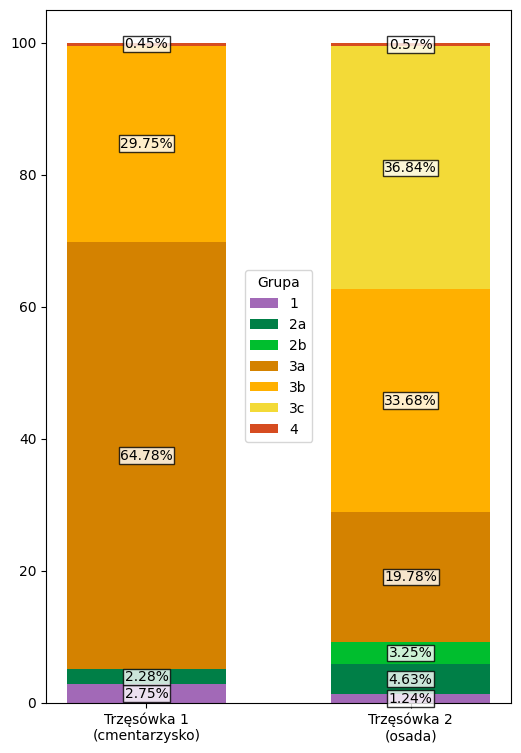

In [33]:
colors = ['#D64C20', '#F3DA37', '#FFB000', '#D48200', '#00BE2E', '#007F47', '#A269B7']
colors.reverse()
chart(joined, colors)

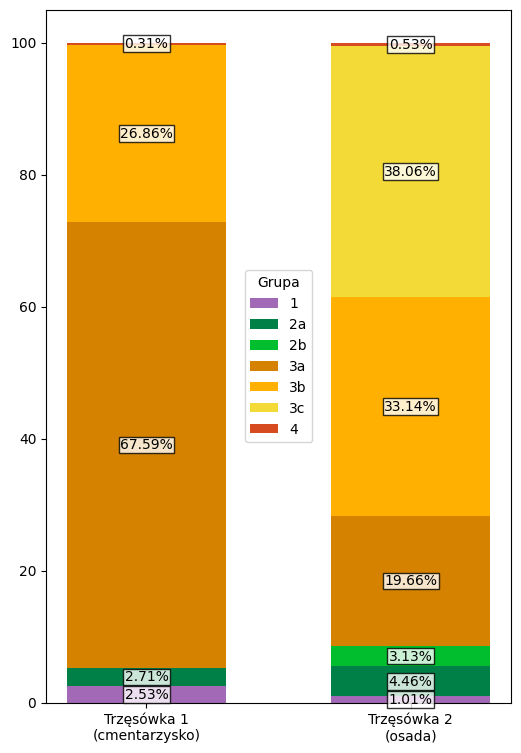

In [34]:
colors = ['#D64C20', '#F3DA37', '#FFB000', '#D48200', '#00BE2E', '#007F47', '#A269B7']
colors.reverse()
chart(joined_mass, colors)

### **exporting the new csvs**

In [35]:
# joined.to_csv('./drive/MyDrive/masta_of_disasta/TEKST/gotowce/skorupy_full.csv', encoding='cp1250')
# joined_mass.to_csv('./drive/MyDrive/masta_of_disasta/TEKST/gotowce/masa_full.csv', encoding='cp1250')
# joined_no3c.to_csv('./drive/MyDrive/masta_of_disasta/TEKST/gotowce/skorupy_bez_3c.csv', encoding='cp1250')
# joined_mass_no3c.to_csv('./drive/MyDrive/masta_of_disasta/TEKST/gotowce/masa_bez_3c.csv', encoding='cp1250')
# joined_sherds_conjoined.to_csv('./drive/MyDrive/masta_of_disasta/TEKST/gotowce/skorupy_nierozdzielone.csv', encoding='cp1250')
# joined_mass_conjoined.to_csv('./drive/MyDrive/masta_of_disasta/TEKST/gotowce/masa_nierozdzielone.csv', encoding='cp1250')
# joined_sherds_no3c_conjoined.to_csv('./drive/MyDrive/masta_of_disasta/TEKST/gotowce/skorupy_nierozdzielone_bez_3c.csv', encoding='cp1250')
# joined_mass_no3c_conjoined.to_csv('./drive/MyDrive/masta_of_disasta/TEKST/gotowce/masa_nierozdzielone_bez_3c.csv', encoding='cp1250')

In [36]:
def wykres(prop: pd.DataFrame, figsize: tuple, labels_y: float, xaxlabel: float, ylim: tuple, ylabel: str):
  from ctypes import alignment
  import matplotlib.pyplot as plt
  import numpy as np

  plt.style.use('default')

  # make data:
  x = prop['odds_ratio'].to_list()
  y = np.arange(1, len(prop.index.to_list()) + 1, 1)
  # xerr = [[item.low for item in od['confidence_interval']],[item.high for item in od['confidence_interval']]]
  xerr = [[x[prop['confidence_interval'].to_list().index(item)] - item.low for item in prop['confidence_interval']], [item.high - (x[prop['confidence_interval'].to_list().index(item)]) for item in prop['confidence_interval']]]
  # for item in xerr:
  #   if item == np.float64(np.nan):
  #     item = np.float64(0.0)

  labels = [decimal(item) for item in x]
  ylabels = prop.index.to_list()
  # print (f'{x}\n{xerr[0]}\n{xerr[1]}\n{labels}')

  def form(x, pos):
      """The two args are the value and tick position.
      Label ticks with the product of the exponentiation"""
      return ("%.2f" % x).rstrip('0').rstrip('.')
  # plot:
  fig, ax = plt.subplots(figsize=figsize)
  ax.set_xscale('symlog', base=10, linthresh=0.1, linscale=0.1)
  formatter = plt.FuncFormatter(form)
  ax.xaxis.set_major_formatter(formatter)
  ax.xaxis.set_minor_formatter(formatter)
  ax.set_yticks(ticks=y, labels=ylabels)
  ax.set_ylabel(ylabel=ylabel, labelpad=10,  size='large', weight='demibold')
  # ax.set_xlabel(xlabel='Osada', x=0.15,  size='large', weight='roman')
  ax.set_xlabel(xlabel='Osada - Cmentarzysko', x=xaxlabel, labelpad=10, size='large', weight='demibold') # i honestly dont give a fuck hahahah
  # error = ax.errorbar(x, y, xerr=xerr, fmt='o', linewidth=2, capsize=6)



  plt.grid(True, which='both')
  plt.axvline(x = 1, color = 'r', label = '1', zorder=2, lw=2)
  plt.axvline(x=10, color='w', visible=False)

  ax.errorbar(x, y, xerr=xerr, fmt='o', linewidth=2, capsize=6, label=x)
  for i, txt in enumerate(labels):
      ax.annotate(txt, (x[i], y[i]), xytext=(x[i], y[i]+labels_y), xycoords='data', backgroundcolor='w', bbox=dict(facecolor='w', alpha=0.8, boxstyle='square'))


  # ax.secondary_xaxis(location='top', xscale='linear')
  # ax.scatter([0, 0], [3, 6])

  # plt.title('Wartości i przedziały ufności odds ratio dla grup technologicznych\nceramiki ze stanowisk Trzęsówka 1 i 2', pad=20.0)
  # ax.set_xticks(ticks=xerr[0]+xerr[1]+[1], labels=labels+['1'], rotation='vertical')
  # ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
  # ax.xaxis.set_minor_formatter(ticker.ScalarFormatter(useMathText=True))

  ax.set(ylim=ylim, xlim=(0, 10), xticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70])
  # ax.set_xticks(

  plt.show()

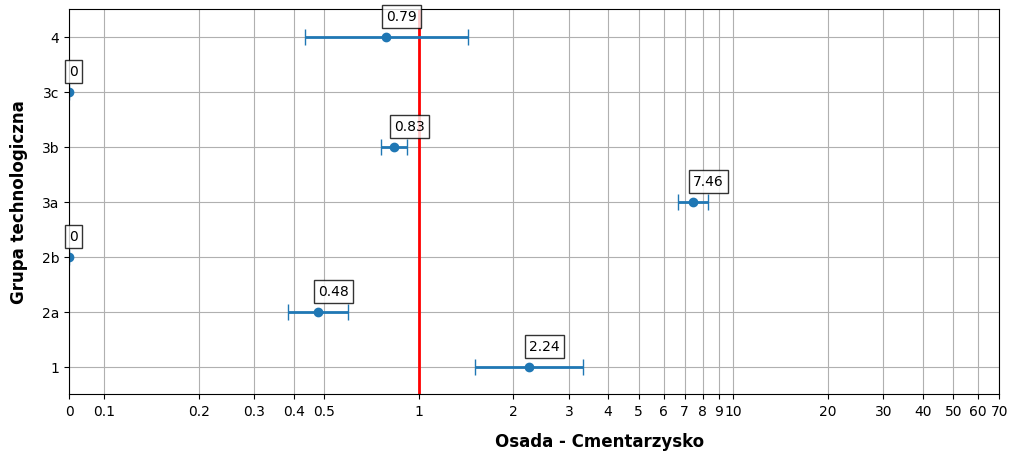

In [37]:
wykres(prop, (12, 5), 0.3, 0.57, (0.5, 7.5), 'Grupa technologiczna')

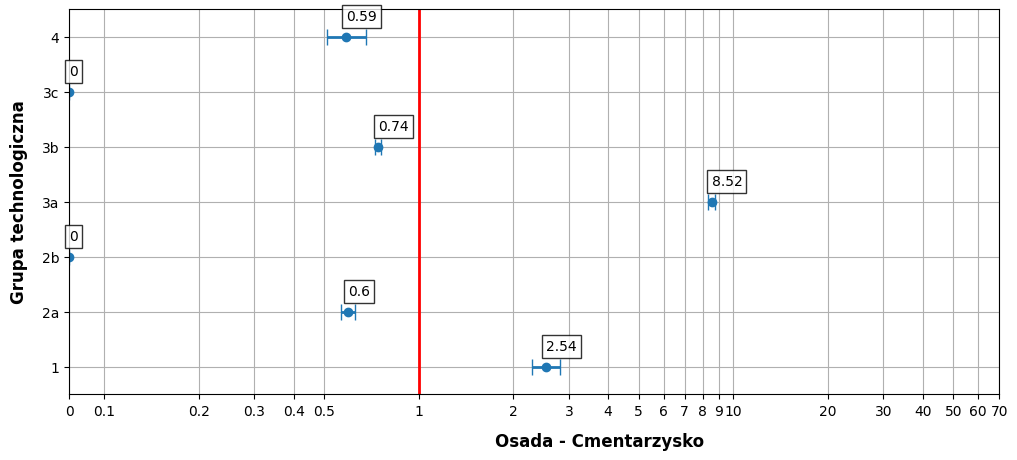

In [38]:
wykres(prop_m, (12, 5), 0.3, 0.57, (0.5, 7.5), 'Grupa technologiczna')

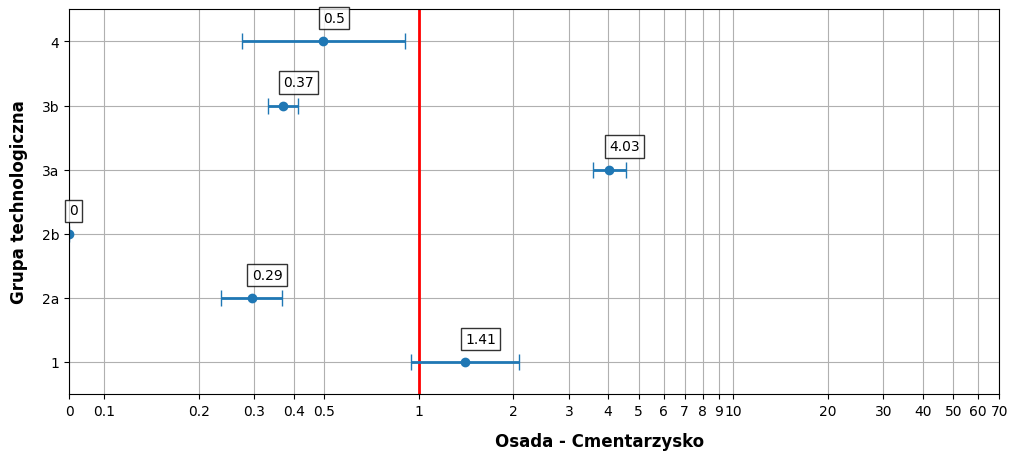

In [39]:
wykres(prop_no3c, (12, 5), 0.3, 0.57, (0.5, 6.5), 'Grupa technologiczna')

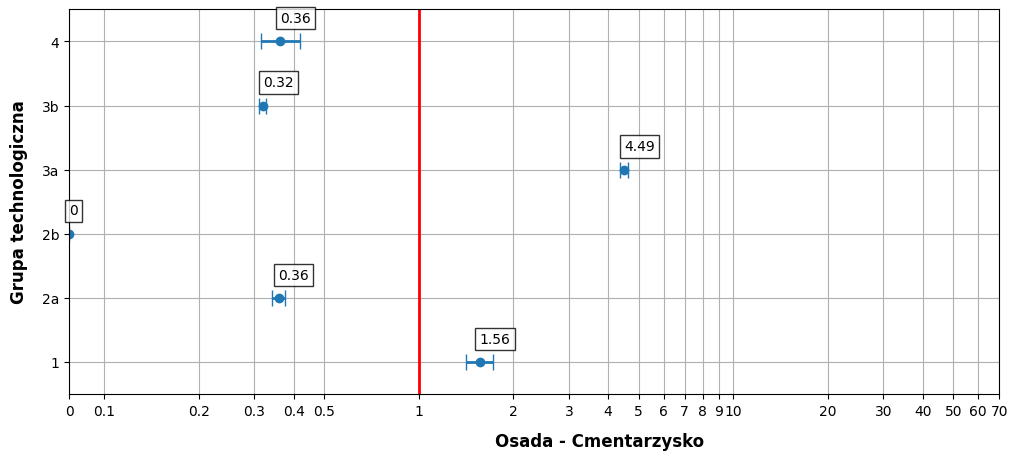

In [40]:
wykres(prop_m_no3c, (12, 5), 0.3, 0.57, (0.5, 6.5), 'Grupa technologiczna')

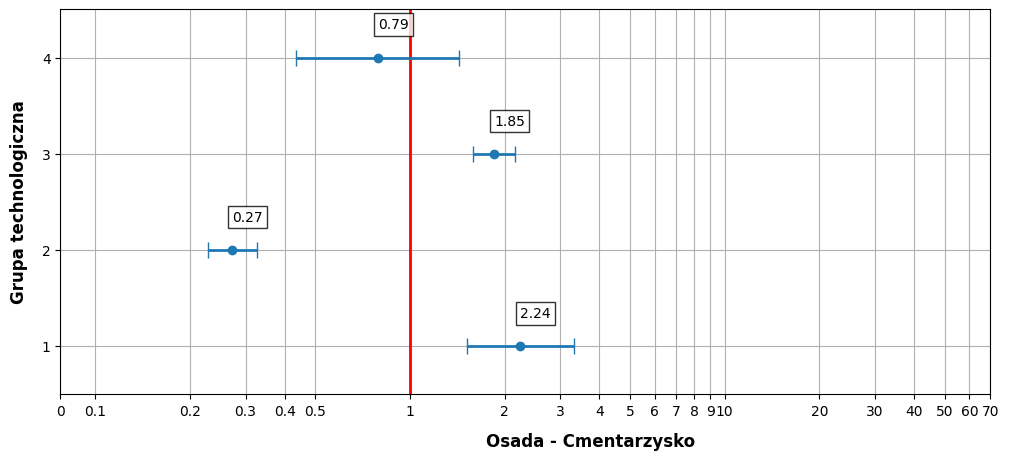

In [41]:
wykres(prop_sherds_conjoined, (12, 5), 0.3, 0.57, (0.5, 4.5), 'Grupa technologiczna')

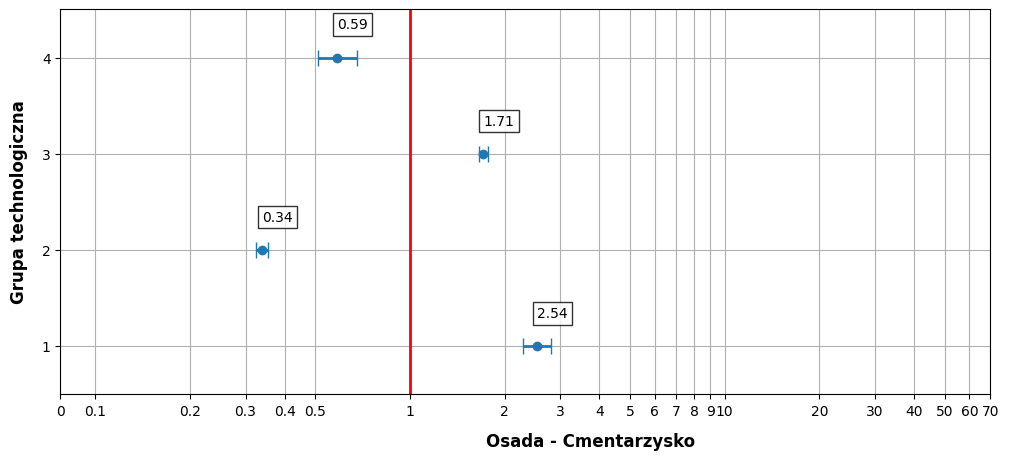

In [42]:
wykres(prop_mass_conjoined, (12, 5), 0.3, 0.57, (0.5, 4.5), 'Grupa technologiczna')

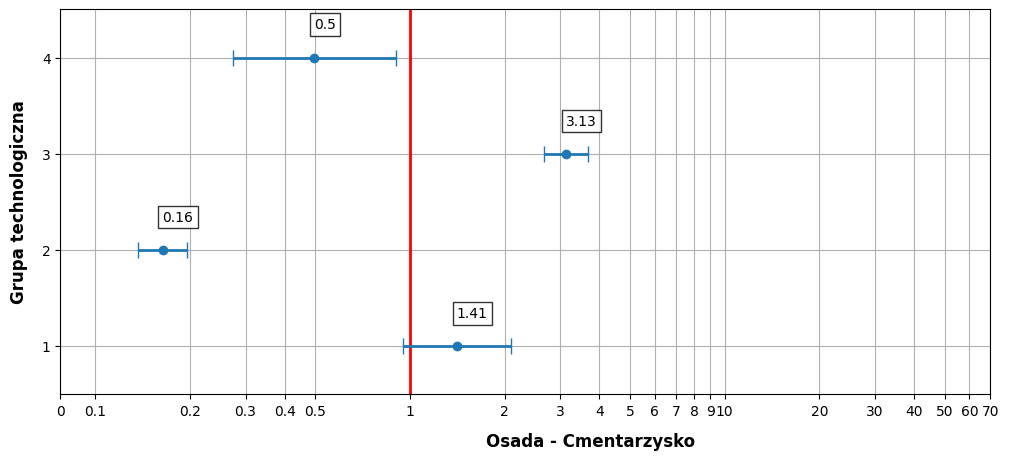

In [43]:
wykres(prop_sherds_conjoined_no3c, (12, 5), 0.3, 0.57, (0.5, 4.5), 'Grupa technologiczna')

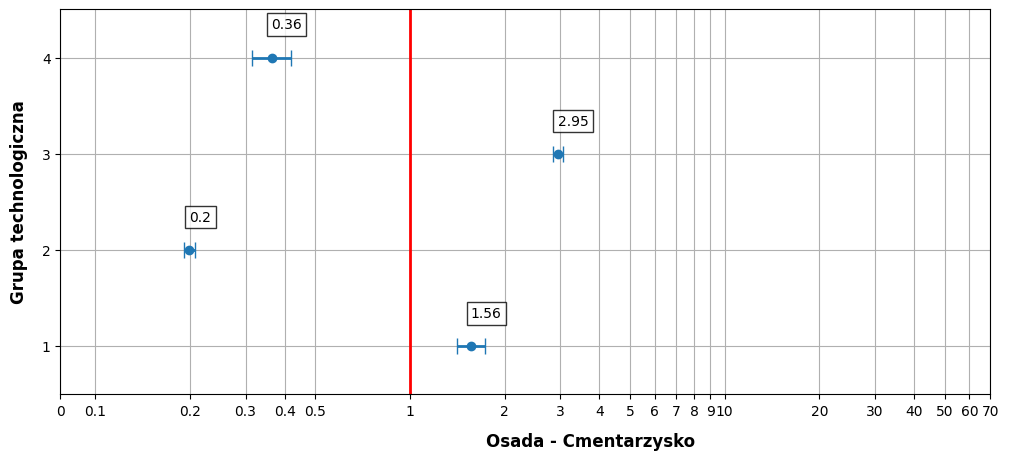

In [44]:
wykres(prop_mass_conjoined_no3c, (12, 5), 0.3, 0.57, (0.5, 4.5), 'Grupa technologiczna')

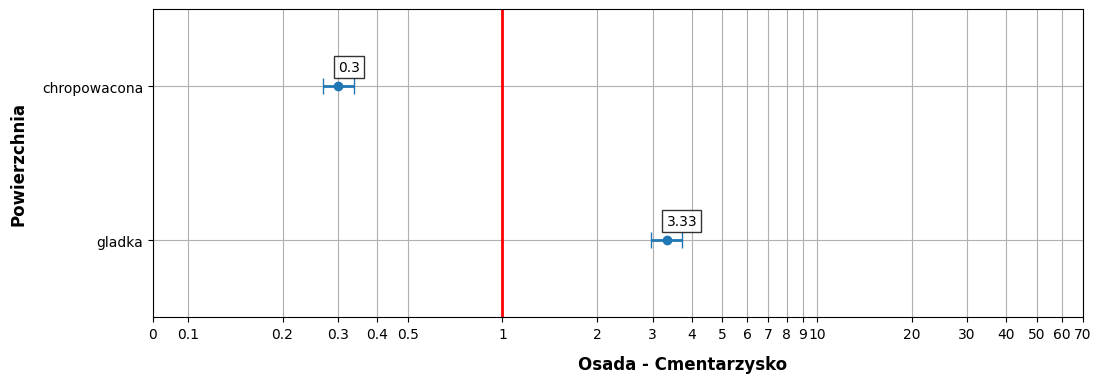

In [45]:
def pow(table: pd.DataFrame) -> pd.DataFrame:
  sites = {}
  for site in table.columns.to_list():
    gladka = 0
    chrop = 0
    for row in table.index.to_list():
      if row == '3c':
        pass
      elif 'b' in row:
        chrop += table[site].loc[row]
      else:
        gladka += table[site].loc[row]
    site_dict = {'gladka': gladka,
                 'chropowacona': chrop}
    site_series = pd.Series(data=site_dict, index=['gladka', 'chropowacona'])
    sites[site] = site_series
  return pd.DataFrame(sites)



nowe = pow(joined)
wykres(odds_ratio_new(nowe), (12, 4), 0.1, 0.57, (0.5, 2.5), 'Powierzchnia')


In [46]:
prop_new = odds_ratio_new(nowe)
prop_new

,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
gladka,17988,549,3.325110,"(2.9709354112424413, 3.7215078146597302)"
chropowacona,7617,773,0.300742,"(0.2687082897047291, 0.336594325213486)"


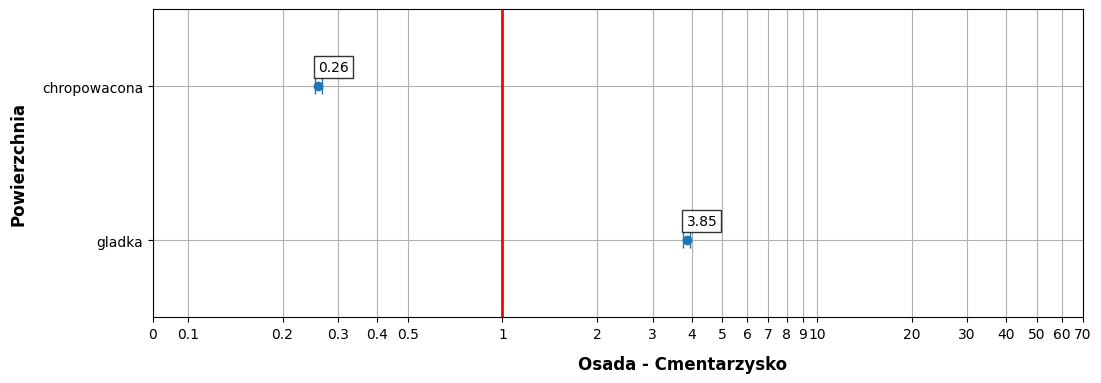

In [47]:
nowe_masa = pow(joined_mass)
wykres(odds_ratio_new(nowe_masa), (12, 4), 0.1, 0.57, (0.5, 2.5), 'Powierzchnia')

In [48]:
prop_new2 = odds_ratio_new(nowe_masa)
prop_new2

,Trzęsówka 1\n(cmentarzysko),Trzęsówka 2\n(osada),odds_ratio,confidence_interval
gladka,438645,10024,3.848530,"(3.748969210746141, 3.9507355643060507)"
chropowacona,161085,14167,0.259839,"(0.2531174217365395, 0.2667399873900203)"


In [49]:
settl_styles = pd.read_csv('/content/drive/MyDrive/masta_of_disasta/TEKST/tekst_nowy/OSADA_STYLE.csv', index_col='Grupa techn.', encoding='cp1250')
cem_styles = pd.read_csv('/content/drive/MyDrive/masta_of_disasta/TEKST/tekst_nowy/CMENT_STYLE.csv', index_col='Grupa techn.', encoding='cp1250')
settl_styles

,guzki miseczkowate,linie ryte,guzki plastyczne,ornament choinkowy,odciski plecionki,otwory na powierzchni,dołki paznokciowe,otwory pod wylewem,dołki palcowe,ornament pseudosznurowy,listwy karbowane,listwy plastyczne,ornament stempelkowy,wcięcia w wylewach,ryte okręgi,nakłuwanie,brak
Grupa techn.,,,,,,,,,,,,,,,,,
1,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0
2a,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.0
2b,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,61.0
3a,0.0,13.0,7.0,3.0,0.0,1.0,7.0,28.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,373.0
3b,11.0,2.0,10.0,0.0,0.0,2.0,76.0,26.0,9.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,599.0
3c,0.0,0.0,1.0,0.0,74.0,133.0,87.0,0.0,11.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,514.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0


In [50]:
def percent(ser: pd.Series) -> pd.Series:
  sum = ser.sum()
  l = [ser[row]/sum*100 for row in ser.index]

  return pd.Series(data=l, index=ser.index)

# def percentage(table: pd.DataFrame) -> pd.DataFrame:
#   dic = {}
#   for j in range(len(table.columns)):
#     data = table[table.columns[j]].to_numpy()
#     dic[table.columns.to_list()[j]] = data
#   for el in dic:
#     summ = dic[el].sum()
#     dic[el] = dic[el]/summ*100
#   out = pd.DataFrame(data=dic, index=table.index, columns=table.columns)
#   return out

In [51]:
# import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA


def pca_summary(pca, standardised_data, out=True):
    names = ["PC"+str(i) for i in range(1, len(pca.explained_variance_ratio_)+1)]
    a = list(np.std(pca.transform(standardised_data), axis=0))
    b = list(pca.explained_variance_ratio_)
    c = [np.sum(pca.explained_variance_ratio_[:i]) for i in range(1, len(pca.explained_variance_ratio_)+1)]
    columns = pd.MultiIndex.from_tuples([("sdev", "Standard deviation"), ("varprop", "Proportion of Variance"), ("cumprop", "Cumulative Proportion")])
    summary = pd.DataFrame(zip(a, b, c), index=names, columns=columns)
    if out:
        print("Importance of components:")
        display(summary)
    return summary


def calcpc(variables, loadings):
    # find the number of samples in the data set and the number of variables
    numsamples, numvariables = variables.shape
    # make a vector to store the component
    pc = np.zeros(numsamples)
    # calculate the value of the component for each sample
    for i in range(numsamples):
        valuei = 0
        for j in range(numvariables):
            valueij = variables.iloc[i, j]
            loadingj = loadings[j]
            valuei = valuei + (valueij * loadingj)
        pc[i] = valuei
    return pc


def pca_scatter(pca, pca_data, standardised_values, features, classifs, v1, v2):
    foo = pca_data
    # bar = pd.DataFrame(zip(foo[:, v1-1], foo[:, v2-1], classifs, concatenated['site']), columns=[f"PC{v1}", f"PC{v2}", "Class", 'site'])
    bar = pd.DataFrame(zip(foo[:, v1-1], foo[:, v2-1], classifs), columns=[f"PC{v1}", f"PC{v2}", "Class"])
    fig, ax = plt.subplots(figsize=(8, 8))
    plt.grid(True, which='both')
    colors = {
        '1': '#1f77b4',
        '2a': '#ff7f0e',
        '2b': '#2ca02c',
        '3a': '#d62728',
        '3b': '#9467bd',
        '3c': '#8c564b',
        '4': '#e377c2'
    }
    for i in bar.index.to_list():
      if bar['site'].loc[i] == '1':
        ax.scatter(bar[bar.columns[0]].loc[i], bar[bar.columns[1]].loc[i], s=80.0, marker='D', c=colors[bar['Class'].loc[i]], zorder=2, alpha=0.75, edgecolors='k')
      else:
        ax.scatter(bar[bar.columns[0]].loc[i], bar[bar.columns[1]].loc[i], s=80.0, marker='o', c=colors[bar['Class'].loc[i]], zorder=2, alpha=0.75, edgecolors='k')

      # ax.scatter(bar[bar.columns[0]].loc[i], bar[bar.columns[1]].loc[i], s=80.0, marker='o', c=colors[bar['Class'].loc[i]], zorder=2, alpha=0.75, edgecolors='k')
# ================================================================
    # explained_variances = pca.explained_variance_ratio_
    # loadings = pca.components_.T * np.sqrt(explained_variances)
    # for i, feature in enumerate(standardised_values.columns):

    #   # Add the name of the variable near the arrow
    #   if loadings[i, 0]>0:
    #     plt.annotate(feature, (loadings[i, 0]+1, loadings[i, 1]*2.5), color='black', bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))
    #   else:
    #     plt.annotate(feature, (loadings[i, 0]-1, loadings[i, 1]*3), color='black', bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))

    #   # Add an arrow representing the variable on the new axis
    #   plt.arrow(0, 0,
    #             loadings[i, 0],
    #             loadings[i, 1],
    #             color='black',
    #             alpha=1.0,
    #             width=0.01,
    #           )
# ==================================================================
    legend1 = ax.legend(colors, loc="lower right", title="Grupa techn.")
    ax.add_artist(legend1)
    cem_line = mlines.Line2D([], [], color='k', marker='D', markersize=7.5, markerfacecolor='w', label='Cmentarzysko', linewidth=0)
    set_line = mlines.Line2D([], [], color='k', marker='o', markersize=7.5, markerfacecolor='w', label='Osada', linewidth=0)
    legend2 = ax.legend(handles=[cem_line, set_line], loc="center right", title="Stanowisko")
    # sns.lmplot(bar, x=f"PC{v1}", y=f"PC{v2}", hue="Class", fit_reg=False, height=6, markers='P')
    # for x, y, s in zip(foo[:, v1-1], foo[:, v2-1], concatenated['site']):
    #   if s == '1':
    #     plt.text(x = x+.1, y = y+.1, s = s, color='black')
    #   else:
    #     plt.text(x = x-.1, y = y+.1, s = s, color='black')
    plt.xlabel(f"PC{v1}")
    plt.ylabel(f"PC{v2}")



def screeplot(pca, standardised_values):
    y = np.std(pca.transform(standardised_values), axis=0)**2
    x = np.arange(len(y)) + 1
    plt.plot(x, y, "o-")
    plt.xticks(x, ["Skł."+str(i) for i in x], rotation=60)
    plt.ylabel("Wariancja")
    plt.grid(True, which='both')
    plt.show()

[Text(0.5, 1, 'guzki miseczkowate'),
 Text(1.5, 1, 'linie ryte'),
 Text(2.5, 1, 'guzki plastyczne'),
 Text(3.5, 1, 'ornament choinkowy'),
 Text(4.5, 1, 'dołki paznokciowe'),
 Text(5.5, 1, 'otwory pod wylewem'),
 Text(6.5, 1, 'dołki palcowe'),
 Text(7.5, 1, 'ornament pseudosznurowy'),
 Text(8.5, 1, 'listwy karbowane'),
 Text(9.5, 1, 'listwy plastyczne'),
 Text(10.5, 1, 'ornament stempelkowy'),
 Text(11.5, 1, 'wcięcia w wylewach'),
 Text(12.5, 1, 'ryte okręgi'),
 Text(13.5, 1, 'nakłuwanie'),
 Text(14.5, 1, 'brak')]

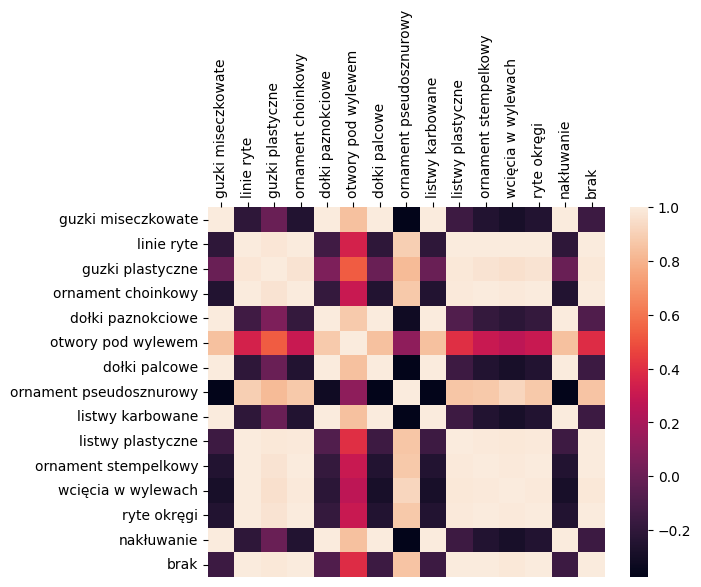

In [52]:
cem_styles_chart = cem_styles.drop(columns=['odciski plecionki', 'otwory na powierzchni'])
corrmat = cem_styles_chart.corr()
square = sns.heatmap(corrmat, vmax=1., square=False)
square.xaxis.tick_top()
square.set_xticklabels(cem_styles_chart.columns.to_list(), rotation=90)

In [53]:
cem_styles_chart

,guzki miseczkowate,linie ryte,guzki plastyczne,ornament choinkowy,dołki paznokciowe,otwory pod wylewem,dołki palcowe,ornament pseudosznurowy,listwy karbowane,listwy plastyczne,ornament stempelkowy,wcięcia w wylewach,ryte okręgi,nakłuwanie,brak
Grupa techn.,,,,,,,,,,,,,,,
1,0.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
2a,0.0,4.0,3.0,0.0,0.0,1.0,0.0,3.0,0.0,1.0,0.0,1.0,0.0,0.0,3.0
3a,0.0,40.0,61.0,6.0,2.0,26.0,0.0,6.0,0.0,36.0,2.0,9.0,1.0,0.0,226.0
3b,21.0,4.0,16.0,0.0,29.0,46.0,4.0,0.0,17.0,4.0,0.0,0.0,0.0,1.0,24.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [54]:
standardised_styles = scale(cem_styles_chart)
standardised_styles = pd.DataFrame(standardised_styles, index=cem_styles_chart.index, columns=cem_styles_chart.columns)
standardised_styles

,guzki miseczkowate,linie ryte,guzki plastyczne,ornament choinkowy,dołki paznokciowe,otwory pod wylewem,dołki palcowe,ornament pseudosznurowy,listwy karbowane,listwy plastyczne,ornament stempelkowy,wcięcia w wylewach,ryte okręgi,nakłuwanie,brak
Grupa techn.,,,,,,,,,,,,,,,
1,-0.5,-0.548670,-0.657178,-0.5,-0.542609,-0.748674,-0.5,-0.75,-0.5,-0.586673,-0.5,-0.567962,-0.5,-0.5,-0.543404
2a,-0.5,-0.414848,-0.570707,-0.5,-0.542609,-0.748674,-0.5,0.50,-0.5,-0.515127,-0.5,-0.283981,-0.5,-0.5,-0.554821
3a,-0.5,1.993947,1.936945,2.0,-0.367574,0.607620,-0.5,1.75,-0.5,1.988964,2.0,1.987866,2.0,-0.5,1.990961
3b,2.0,-0.414848,-0.008647,-0.5,1.995399,1.692655,2.0,-0.75,2.0,-0.300491,-0.5,-0.567962,-0.5,2.0,-0.315083
4,-0.5,-0.615581,-0.700413,-0.5,-0.542609,-0.802926,-0.5,-0.75,-0.5,-0.586673,-0.5,-0.567962,-0.5,-0.5,-0.577653


In [55]:
pca_styles = PCA()
pca_styles.fit(standardised_styles)
pca_data = pca_styles.transform(standardised_styles)

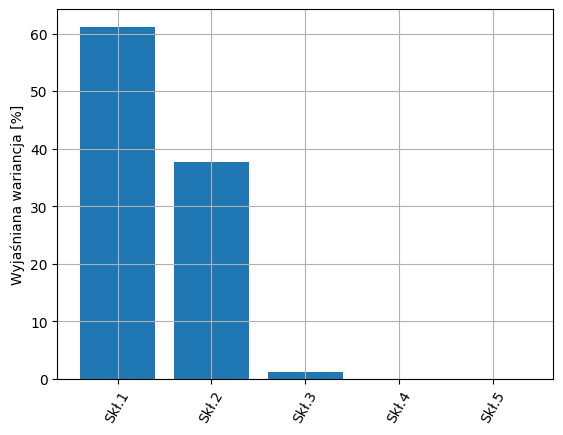

In [56]:
expl_var = pca_styles.explained_variance_ratio_*100
labels = ["Skł."+str(i) for i in range(1, len(expl_var)+1)]

plt.bar(range(1, len(expl_var)+1), expl_var)
plt.xticks(range(1, len(expl_var)+1), labels, rotation=60)
plt.ylabel("Wyjaśniana wariancja [%]")
plt.grid(True, which='both')
plt.show()

In [57]:
pd.DataFrame(zip(pca_data[:, 0], pca_data[:, 1], standardised_styles.index), columns=["PC1", "PC2", "Class"])

,PC1,PC2,Class
0,-1.346484,-1.704486,1
1,-0.785621,-1.664338,2a
2,5.964635,0.765124,3a
3,-2.437823,4.347442,3b
4,-1.394706,-1.743742,4


In [58]:
# pca_styles.explained_variance_ratio_
pd.DataFrame(pca_styles.components_.T * np.sqrt(pca_styles.explained_variance_ratio_), index=standardised_styles.columns, columns=["Skł."+str(i) for i in range(1, len(expl_var)+1)])

,Skł.1,Skł.2,Skł.3,Skł.4,Skł.5
guzki miseczkowate,-0.103879,0.236323,0.005170,-0.000669,5.872599e-17
linie ryte,0.252732,0.052645,-0.002569,0.003895,4.686755e-17
guzki plastyczne,0.236653,0.102973,-0.007473,0.001738,-2.944367e-17
ornament choinkowy,0.254161,0.041591,-0.018335,-0.001651,2.624162e-18
dołki paznokciowe,-0.087663,0.242828,0.003965,-0.000795,1.033046e-17
otwory pod wylewem,0.037736,0.255398,-0.002480,0.002884,-2.568993e-17
dołki palcowe,-0.103879,0.236323,0.005170,-0.000669,-1.297688e-17
ornament pseudosznurowy,0.237423,-0.003645,0.101408,-0.000324,3.275816e-18
listwy karbowane,-0.103879,0.236323,0.005170,-0.000669,-1.297688e-17
listwy plastyczne,0.249001,0.067313,-0.011444,-0.001701,1.034918e-17


In [59]:
pca_styles.components_

array([[-0.13279272,  0.32307757,  0.30252268,  0.32490463, -0.11206371,
         0.04823883, -0.13279272,  0.30350751, -0.13279272,  0.31830873,
         0.32490463,  0.32729907,  0.32490463, -0.13279272,  0.31847925],
       [ 0.38538968,  0.08585155,  0.16792491,  0.0678263 ,  0.39599757,
         0.41649669,  0.38538968, -0.00594337,  0.38538968,  0.10977269,
         0.0678263 ,  0.05258161,  0.0678263 ,  0.38538968,  0.10674705],
       [ 0.04720203, -0.02345089, -0.06822664, -0.1673863 ,  0.03620026,
        -0.02263718,  0.04720203,  0.92578013,  0.04720203, -0.10447831,
        -0.1673863 ,  0.07722647, -0.1673863 ,  0.04720203, -0.16142225],
       [-0.10186781,  0.593022  ,  0.26464959, -0.25136426, -0.12101553,
         0.43914018, -0.10186781, -0.04928083, -0.10186781, -0.25906382,
        -0.25136426, -0.21106728, -0.25136426, -0.10186781,  0.16013871],
       [ 0.60743878,  0.48477961, -0.30455385,  0.02714331,  0.10685423,
        -0.26572663, -0.13422775,  0.03388377, 

In [60]:
# pca_scatter(pca_styles, pca_data, standardised_styles, standardised_styles.columns.to_list(), standardised_styles.index, v1=1, v2=2)

In [61]:
cem_styles_chart.T

Grupa techn.,1,2a,3a,3b,4
guzki miseczkowate,0.0,0.0,0.0,21.0,0.0
linie ryte,2.0,4.0,40.0,4.0,1.0
guzki plastyczne,1.0,3.0,61.0,16.0,0.0
ornament choinkowy,0.0,0.0,6.0,0.0,0.0
dołki paznokciowe,0.0,0.0,2.0,29.0,0.0
otwory pod wylewem,1.0,1.0,26.0,46.0,0.0
dołki palcowe,0.0,0.0,0.0,4.0,0.0
ornament pseudosznurowy,0.0,3.0,6.0,0.0,0.0
listwy karbowane,0.0,0.0,0.0,17.0,0.0
listwy plastyczne,0.0,1.0,36.0,4.0,0.0


[Text(0.5, 1, 'guzki miseczkowate'),
 Text(1.5, 1, 'linie ryte'),
 Text(2.5, 1, 'guzki plastyczne'),
 Text(3.5, 1, 'ornament choinkowy'),
 Text(4.5, 1, 'odciski plecionki'),
 Text(5.5, 1, 'otwory na powierzchni'),
 Text(6.5, 1, 'dołki paznokciowe'),
 Text(7.5, 1, 'otwory pod wylewem'),
 Text(8.5, 1, 'dołki palcowe'),
 Text(9.5, 1, 'ornament pseudosznurowy'),
 Text(10.5, 1, 'listwy karbowane'),
 Text(11.5, 1, 'listwy plastyczne'),
 Text(12.5, 1, 'brak')]

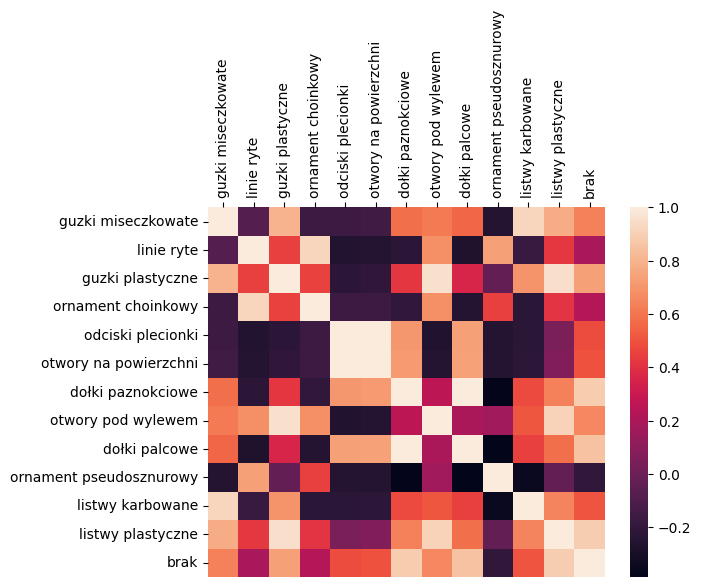

In [62]:
settl_styles_chart = settl_styles.drop(columns=['ornament stempelkowy', 'wcięcia w wylewach', 'ryte okręgi', 'nakłuwanie'])
corrmat = settl_styles_chart.corr()
square = sns.heatmap(corrmat, vmax=1., square=False)
square.xaxis.tick_top()
square.set_xticklabels(settl_styles_chart.columns.to_list(), rotation=90)

In [129]:
settl_styles_chart

,guzki miseczkowate,linie ryte,guzki plastyczne,ornament choinkowy,odciski plecionki,otwory na powierzchni,dołki paznokciowe,otwory pod wylewem,dołki palcowe,ornament pseudosznurowy,listwy karbowane,listwy plastyczne,brak
Grupa techn.,,,,,,,,,,,,,
1,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,23.0
2a,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,96.0
2b,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,2.0,0.0,61.0
3a,0.0,13.0,7.0,3.0,0.0,1.0,7.0,28.0,0.0,2.0,0.0,2.0,373.0
3b,11.0,2.0,10.0,0.0,0.0,2.0,76.0,26.0,9.0,0.0,5.0,3.0,599.0
3c,0.0,0.0,1.0,0.0,74.0,133.0,87.0,0.0,11.0,0.0,0.0,1.0,514.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0


In [63]:
standardised_styles = scale(settl_styles_chart)
standardised_styles = pd.DataFrame(standardised_styles, index=settl_styles_chart.index, columns=settl_styles_chart.columns)
standardised_styles

,guzki miseczkowate,linie ryte,guzki plastyczne,ornament choinkowy,odciski plecionki,otwory na powierzchni,dołki paznokciowe,otwory pod wylewem,dołki palcowe,ornament pseudosznurowy,listwy karbowane,listwy plastyczne,brak
Grupa techn.,,,,,,,,,,,,,
1,-0.408248,0.477697,-0.836660,-0.408248,-0.408248,-0.418983,-0.695826,-0.648091,-0.628074,1.969464,-0.564076,-0.762001,-0.938197
2a,-0.408248,-0.636930,-0.557773,-0.408248,-0.408248,-0.418983,-0.667993,-0.648091,-0.628074,-0.615457,-0.564076,-0.762001,-0.622166
2b,-0.408248,-0.636930,-0.557773,-0.408248,-0.408248,-0.418983,-0.584494,-0.565607,-0.628074,-0.615457,0.564076,-0.762001,-0.773688
3a,-0.408248,2.261101,1.115547,2.449490,-0.408248,-0.397418,-0.500995,1.661470,-0.628074,1.107823,-0.564076,1.016001,0.577019
3b,2.449490,-0.191079,1.952207,-0.408248,-0.408248,-0.375853,1.419486,1.496502,1.350360,-0.615457,2.256304,1.905002,1.555415
3c,-0.408248,-0.636930,-0.557773,-0.408248,2.449490,2.449205,1.725650,-0.648091,1.790012,-0.615457,-0.564076,0.127000,1.187434
4,-0.408248,-0.636930,-0.557773,-0.408248,-0.408248,-0.418983,-0.695826,-0.648091,-0.628074,-0.615457,-0.564076,-0.762001,-0.985818


In [64]:
pca_styles = PCA()
pca_styles.fit(standardised_styles)
pca_data = pca_styles.transform(standardised_styles)

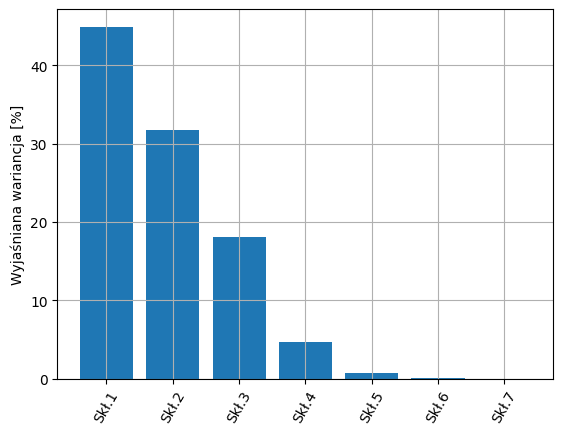

In [65]:
expl_var = pca_styles.explained_variance_ratio_*100
labels = ["Skł."+str(i) for i in range(1, len(expl_var)+1)]

plt.bar(range(1, len(expl_var)+1), expl_var)
plt.xticks(range(1, len(expl_var)+1), labels, rotation=60)
plt.ylabel("Wyjaśniana wariancja [%]")
plt.grid(True, which='both')
plt.show()

In [66]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

# n = 100

# # For each set of style and range settings, plot n random points in the box
# # defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
# for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
#     xs = randrange(n, 23, 32)
#     ys = randrange(n, 0, 100)
#     zs = randrange(n, zlow, zhigh)
#     ax.scatter(xs, ys, zs, marker=m)

# ax.set_xlabel('X Label')
# ax.set_ylabel('Y Label')
# ax.set_zlabel('Z Label')

# plt.show()


def pca_scatter_3d(pca, pca_data, standardised_values, features, classifs, v1, v2, v3):
    foo = pca_data
    # bar = pd.DataFrame(zip(foo[:, v1-1], foo[:, v2-1], classifs, concatenated['site']), columns=[f"PC{v1}", f"PC{v2}", "Class", 'site'])
    bar = pd.DataFrame(zip(foo[:, v1-1], foo[:, v2-1], foo[:, v3-1], classifs), columns=[f"PC{v1}", f"PC{v2}", f"PC{v3}", "Class"])

    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(projection='3d')
    plt.grid(True, which='both')
    colors = {
        '1': '#1f77b4',
        '2a': '#ff7f0e',
        '2b': '#2ca02c',
        '3a': '#d62728',
        '3b': '#9467bd',
        '3c': '#8c564b',
        '4': '#e377c2'
    }
    for i in bar.index.to_list():


      # ax.scatter(bar[bar.columns[0]].loc[i], bar[bar.columns[1]].loc[i], s=80.0, marker='o', c=colors[bar['Class'].loc[i]], zorder=2, alpha=0.75, edgecolors='k')

      xs = bar[bar.columns[0]].loc[i]
      ys = bar[bar.columns[1]].loc[i]
      zs = bar[bar.columns[2]].loc[i]
      ax.scatter(xs, ys, zs, marker='o', c=colors[bar['Class'].loc[i]], zorder=2, alpha=1)

    ax.set_xlabel(f"PC{v1}")
    ax.set_ylabel(f"PC{v2}")
    ax.set_zlabel(f"PC{v3}", rotation='vertical')

    legend1 = ax.legend(colors, loc="upper left", title="Grupa techn.")
    ax.add_artist(legend1)
    fig.subplots_adjust(right=2)

    # plt.xlabel(f"PC{v1}")
    # plt.ylabel(f"PC{v2}")



# def screeplot(pca, standardised_values):
#     y = np.std(pca.transform(standardised_values), axis=0)**2
#     x = np.arange(len(y)) + 1
#     plt.plot(x, y, "o-")
#     plt.xticks(x, ["Skł."+str(i) for i in x], rotation=60)
#     plt.ylabel("Wariancja")
#     plt.grid(True, which='both')
#     plt.show()

In [67]:
# pca_scatter(pca_styles, pca_data, standardised_styles, standardised_styles.columns.to_list(), standardised_styles.index, v1=1, v2=2)

In [68]:
# pca_scatter(pca_styles, pca_data, standardised_styles, standardised_styles.columns.to_list(), standardised_styles.index, v1=2, v2=3)

In [69]:
# pca_scatter_3d(pca_styles, pca_data, standardised_styles, standardised_styles.columns.to_list(), standardised_styles.index, v1=1, v2=2, v3=3)

In [70]:
pd.DataFrame(pca_styles.components_.T * np.sqrt(pca_styles.explained_variance_ratio_), index=standardised_styles.columns, columns=["Skł."+str(i) for i in range(1, len(expl_var)+1)])

,Skł.1,Skł.2,Skł.3,Skł.4,Skł.5,Skł.6,Skł.7
guzki miseczkowate,0.228770,0.027113,0.142504,0.052344,-0.028272,-0.002369,-5.814280e-18
linie ryte,0.040721,0.224333,-0.156158,0.021453,0.009611,-0.001337,-3.959412e-18
guzki plastyczne,0.237088,0.137005,0.030847,-0.027805,-0.014305,-0.003547,-2.930150e-18
ornament choinkowy,0.044581,0.200486,-0.165559,-0.083948,0.016723,-0.002035,-4.839248e-18
odciski plecionki,0.071285,-0.214232,-0.160543,-0.001869,0.012476,-0.003611,7.347243e-18
otwory na powierzchni,0.075334,-0.213093,-0.160228,-0.001719,0.012222,-0.003675,-7.031831e-18
dołki paznokciowe,0.229323,-0.148664,-0.037686,0.028369,-0.000866,-0.002663,-6.440206e-18
otwory pod wylewem,0.205751,0.181875,-0.024191,-0.030250,-0.000630,-0.003252,9.250610e-18
dołki palcowe,0.218697,-0.162503,-0.037187,0.034657,-0.009016,-0.004696,4.196510e-18
ornament pseudosznurowy,-0.066297,0.159835,-0.124179,0.177617,0.003274,0.001314,1.382098e-18


In [71]:
cem_styles.sum()

,0
guzki miseczkowate,21.0
linie ryte,51.0
guzki plastyczne,81.0
ornament choinkowy,6.0
odciski plecionki,0.0
otwory na powierzchni,0.0
dołki paznokciowe,31.0
otwory pod wylewem,74.0
dołki palcowe,4.0
ornament pseudosznurowy,9.0


In [72]:
settl_styles.sum()

,0
guzki miseczkowate,11.0
linie ryte,20.0
guzki plastyczne,21.0
ornament choinkowy,3.0
odciski plecionki,74.0
otwory na powierzchni,136.0
dołki paznokciowe,175.0
otwory pod wylewem,55.0
dołki palcowe,20.0
ornament pseudosznurowy,5.0


In [73]:
styl_for_odds = pd.DataFrame({'Trzęsówka 1 (cmentarzysko)': cem_styles.sum(), 'Trzęsówka 2 (osada)': settl_styles.sum()}, index=cem_styles.sum().index, columns=['Trzęsówka 1 (cmentarzysko)', 'Trzęsówka 2 (osada)'])

In [74]:
styl_prop = odds_ratio_new(styl_for_odds)
styl_prop

/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:155: RuntimeWarning: divide by zero encountered in log
  log_or = np.log(oddsratio)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:156: RuntimeWarning: divide by zero encountered in divide
  se = np.sqrt((1/table).sum())
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:169: RuntimeWarning: invalid value encountered in scalar add
  loghigh = log_or + z*se
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:168: RuntimeWarning: invalid value encountered in scalar subtract
  loglow = log_or - z*se


,Trzęsówka 1 (cmentarzysko),Trzęsówka 2 (osada),odds_ratio,confidence_interval
guzki miseczkowate,21,11,7.167235,"(3.4361987596973935, 14.949445079131396)"
linie ryte,51,20,10.048651,"(5.941883294662209, 16.993835708780164)"
guzki plastyczne,81,21,16.059207,"(9.845235756808215, 26.19522115279858)"
ornament choinkowy,6,3,7.347754,"(1.8322784687403562, 29.465764074639445)"
odciski plecionki,0,74,0.000000,"(0.0, nan)"
otwory na powierzchni,0,136,0.000000,"(0.0, nan)"
dołki paznokciowe,31,175,0.626151,"(0.42268259229193766, 0.9275631964486678)"
otwory pod wylewem,74,55,5.442402,"(3.7910128066227524, 7.813145354103949)"
dołki palcowe,4,20,0.726700,"(0.24745281139218067, 2.1341145651195554)"
ornament pseudosznurowy,9,5,6.640134,"(2.217073970346672, 19.887192396937177)"


/tmp/ipython-input-104346588.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  xerr = [[x[prop['confidence_interval'].to_list().index(item)] - item.low for item in prop['confidence_interval']], [item.high - (x[prop['confidence_interval'].to_list().index(item)]) for item in prop['confidence_interval']]]


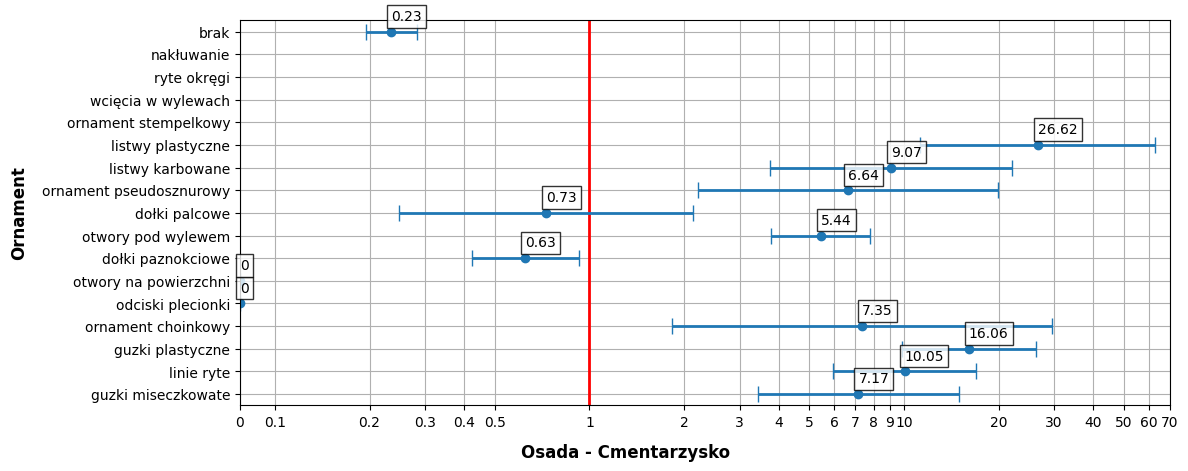

In [75]:
wykres(styl_prop, (12, 5), 0.5, 0.415, (0.5, 17.5), 'Ornament')

In [128]:
all_styles = {}

for orn in cem_styles.columns.to_list():
  column_cem = np.insert(np.insert(cem_styles[orn].to_numpy(), 2, 0), 5, 0)
  column_set = settl_styles[orn].to_numpy()
  all_styles[orn] = column_cem + column_set

styles_summed = pd.DataFrame(data=all_styles, index=settl_styles.index.to_list())
styles_summed = styles_summed.reindex(['dołki palcowe', 'dołki paznokciowe', 'guzki miseczkowate', 'guzki plastyczne', 'listwy karbowane', 'listwy plastyczne', 'odciski plecionki', 'otwory na powierzchni', 'otwory pod wylewem', 'wcięcia w wylewach', 'linie ryte', 'ornament choinkowy', 'nakłuwanie', 'ryte okręgi', 'ornament pseudosznurowy', 'ornament stempelkowy', 'brak'], axis=1)
styles_summed

,dołki palcowe,dołki paznokciowe,guzki miseczkowate,guzki plastyczne,listwy karbowane,listwy plastyczne,odciski plecionki,otwory na powierzchni,otwory pod wylewem,wcięcia w wylewach,linie ryte,ornament choinkowy,nakłuwanie,ryte okręgi,ornament pseudosznurowy,ornament stempelkowy,brak
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,0.0,0.0,0.0,3.0,0.0,27.0
2a,0.0,1.0,0.0,4.0,0.0,1.0,0.0,0.0,1.0,1.0,4.0,0.0,0.0,0.0,3.0,0.0,99.0
2b,0.0,4.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0
3a,0.0,9.0,0.0,68.0,0.0,38.0,0.0,1.0,54.0,9.0,53.0,9.0,0.0,1.0,8.0,2.0,599.0
3b,13.0,105.0,32.0,26.0,22.0,7.0,0.0,2.0,72.0,0.0,6.0,0.0,1.0,0.0,0.0,0.0,623.0
3c,11.0,87.0,0.0,1.0,0.0,1.0,74.0,133.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,514.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,13.0


In [77]:
prop_styles = odds_ratio_new(styles_summed)
prop_styles

/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:155: RuntimeWarning: divide by zero encountered in log
  log_or = np.log(oddsratio)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:156: RuntimeWarning: divide by zero encountered in divide
  se = np.sqrt((1/table).sum())
/usr/local/lib/python3.12/dist-packages/scipy/stats/_odds_ratio.py:169: RuntimeWarning: invalid value encountered in scalar add
  loghigh = log_or + z*se


,dołki palcowe,dołki paznokciowe,odds_ratio,confidence_interval,guzki miseczkowate,guzki plastyczne,listwy karbowane,listwy plastyczne,odciski plecionki,otwory na powierzchni,otwory pod wylewem,wcięcia w wylewach,linie ryte,ornament choinkowy,nakłuwanie,ryte okręgi,ornament pseudosznurowy,ornament stempelkowy,brak
1,5,5,8.000000,"(2.169566897417676, 29.49897515314043)",5,5,5,5,5,5,5,5,10,5,5,5,8,5,28
2a,2,3,4.827586,"(0.7737606584562146, 30.11989344549577)",2,3,2,2,2,2,2,2,2,2,2,2,2,2,98
2b,0,4,0.000000,"(0.0, nan)",0,2,2,0,0,0,2,0,2,0,0,0,0,0,65
3a,0,7,0.000000,"(0.0, nan)",0,10,0,3,0,1,29,1,17,3,0,0,5,0,376
3b,9,78,0.708042,"(0.31056731205630744, 1.6142182222222963)",11,71,5,39,0,2,52,9,42,6,0,1,6,2,825
3c,15,116,0.783944,"(0.36873499823281747, 1.6666932729907626)",21,17,17,5,74,133,46,0,4,0,1,0,0,0,538
4,0,0,NaN,"(0, inf)",0,1,0,0,0,0,0,0,1,0,0,0,0,0,13


In [78]:
# settl_styles.insert(0, 'site', ['2' for i in range(len(settl_styles.index.to_list()))])
# settl_styles

In [79]:
# cem_styles.insert(0, 'site', ['1' for i in range(len(cem_styles.index.to_list()))])
# cem_styles

In [80]:
# concatenated = pd.concat([settl_styles, cem_styles])
# concatenated

[Text(0.5, 1, 'dołki palcowe'),
 Text(1.5, 1, 'dołki paznokciowe'),
 Text(2.5, 1, 'guzki miseczkowate'),
 Text(3.5, 1, 'guzki plastyczne'),
 Text(4.5, 1, 'listwy karbowane'),
 Text(5.5, 1, 'listwy plastyczne'),
 Text(6.5, 1, 'odciski plecionki'),
 Text(7.5, 1, 'otwory na powierzchni'),
 Text(8.5, 1, 'otwory pod wylewem'),
 Text(9.5, 1, 'wcięcia w wylewach'),
 Text(10.5, 1, 'linie ryte'),
 Text(11.5, 1, 'ornament choinkowy'),
 Text(12.5, 1, 'nakłuwanie'),
 Text(13.5, 1, 'ryte okręgi'),
 Text(14.5, 1, 'ornament pseudosznurowy'),
 Text(15.5, 1, 'ornament stempelkowy')]

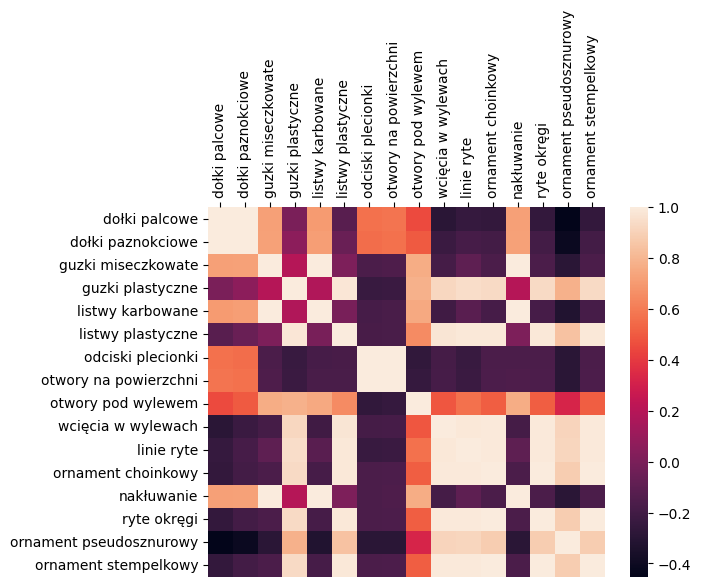

In [130]:
styles_summed.drop('brak', inplace=True, axis=1)
corrmat = styles_summed.corr()
square = sns.heatmap(corrmat, vmax=1., square=False)
square.xaxis.tick_top()
square.set_xticklabels(styles_summed.columns.to_list(), rotation=90)

In [82]:
# standardised_styles = scale(concatenated.loc[:, concatenated.columns != 'site'])
# standardised_styles = pd.DataFrame(standardised_styles, index=concatenated.index, columns=concatenated.loc[:, concatenated.columns != 'site'].columns)
# standardised_styles

In [83]:
# pca_styles = PCA()
# pca_styles.fit(standardised_styles)
# pca_data = pca_styles.transform(standardised_styles)
# # pca_data

# # pca = PCA().fit(standardised_styles)
# # summary = pca_summary(pca, standardised_styles, False)
# # summary

In [84]:
# # screeplot(pca, standardised_styles)
# expl_var = pca_styles.explained_variance_ratio_*100
# labels = ["Skł."+str(i) for i in range(1, len(expl_var)+1)]

# plt.bar(range(1, len(expl_var)+1), expl_var)
# plt.xticks(range(1, len(expl_var)+1), labels, rotation=60)
# plt.ylabel("Wariancja")
# plt.grid(True, which='both')
# plt.show()

In [85]:
# pca_scatter(pca_styles, pca_data, standardised_styles, standardised_styles.columns.to_list(), standardised_styles.index, v1=3, v2=4)

# pca_df = pd.DataFrame(zip(foo[:, v1-1], foo[:, v2-1], classifs, concatenated['site']), pca_data, index=)

In [86]:
settlement_raw.fillna(value={'Domieszka': 'k'}, inplace=True)
# settlement_raw

In [87]:
def domieszka(df: pd.DataFrame)-> pd.DataFrame:

  string_dict = {'k': 'tłuczeń kamienny',
                '0': 'brak widocznej dom.',
                '0/k': 'tłuczeń kam./ brak',
                '0/k/p': 'tłuczeń kam., piasek/ brak',
                '0/k/p?': 'tłuczeń kam., piasek/ brak',
                '0/k/s?': 'tłuczeń kam., szamot/ brak',
                'g': 'tłuczeń kam./ brak',
                'k(s?)': 'tłuczeń kam., możliwy szamot',
                'k, s': 'tłuczeń kam., szamot',
                'k, s?': 'tłuczeń kam., możliwy szamot',
                'k, s?, roĹ›l': 'tłuczeń kam., dom. roślinna, możliwy szamot',
                'k/s?': 'tłuczeń kam./ szamot',
                'k/s?/r?': 'tłuczeń kam./ szamot/ dom. roślinna',
                's': 'szamot',
                'k+s': 'tłuczeń kam., szamot',
                'roślinna?': 'możliwa dom. roślinna',
                'k/s': 'tłuczeń kam./ szamot',
                ' k': 'tłuczeń kamienny',
                'k ': 'tłuczeń kamienny'}

  for row in df.index:
    for key in string_dict.keys():
      if df.loc[row, 'Domieszka'] == key:
        df.loc[row, 'Domieszka'] = string_dict[key]

  # return df ------> pointless


def dom_cols(df: pd.DataFrame):

  kam = []
  szam = []
  rosl = []
  pias = []
  br = []
  mozl = []

#  skrócić co następuje do postaci jednej funkcji:
  for row in df.index:
    if '0/' in str(df.loc[row, 'Domieszka']):
      mozl.append(1)
      kam.append(0)
      szam.append(0)
      rosl.append(0)
      pias.append(0)
      br.append(0)
    else:

      mozl.append(0)

      if 'k' in str(df.loc[row, 'Domieszka']):
        kam.append(1)
      else:
        kam.append(0)

      if 's' in str(df.loc[row, 'Domieszka']):
        szam.append(1)
      else:
        szam.append(0)

      if 'r' in str(df.loc[row, 'Domieszka']):
        rosl.append(1)
      else:
        rosl.append(0)

      if 'p' in str(df.loc[row, 'Domieszka']):
        pias.append(1)
      else:
        pias.append(0)

      if '0' in str(df.loc[row, 'Domieszka']):
        br.append(1)
      else:
        br.append(0)


    # for arr, label in [kam, szam, rosl, pias, br], ['tłuczeń', 'szamot', 'roślinna', 'piasek', 'brak']:
    #   df.insert(loc=4, column=label, value=arr)    --------------> ERROR: TOO MANY VALUES TO UNPACK
# ------------------------------------------------------------
  df.insert(loc=4, column='tłuczeń', value=kam)
  df.insert(loc=4, column='szamot', value=szam)
  df.insert(loc=4, column='roślinna', value=rosl)
  df.insert(loc=4, column='piasek', value=pias)
  df.insert(loc=4, column='brak', value=br)
  df.insert(loc=4, column='możliwa', value=mozl)


In [88]:
dom_cols(cemetery_raw)
cemetery_raw

,Grób,Barwa zewn.,Barwa wewn.,Faktura,możliwa,brak,piasek,roślinna,szamot,tłuczeń,...,dołki paznokciowe,otwory pod wylewem,dołki palcowe,ornament pseudosznurowy,listwy karbowane,listwy plastyczne,ornament stempelkowy,wcięcia w wylewach,ryte okręgi,nakłuwanie
1,1,b,b,g,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,b,b,g,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,b,b,g,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,b,b,g,0,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4,b,b,g,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480,luz,b,b,g,0,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
481,ar 1 ćw. C,b,b,g,0,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
482,ar 1 ćw. C,b,b,ch,0,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
483,luz,b,b,g,0,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
cols = ['możliwa', 'brak', 'piasek', 'roślinna', 'szamot', 'tłuczeń']
# print(cemetery_raw.index)
# print(cemetery_raw['Ilość skorup'])

for col in cols:
  for row in cemetery_raw.index:
    cemetery_raw.loc[row, col] = cemetery_raw.loc[row, col] * cemetery_raw.loc[row, 'Ilość skorup']

In [90]:
cemetery_raw.columns

Index(['Grób', 'Barwa zewn.', 'Barwa wewn.', 'Faktura', 'możliwa', 'brak',
       'piasek', 'roślinna', 'szamot', 'tłuczeń', 'Domieszka', 'Ornament',
       'Uwagi', 'Grupa techn.', 'Masa [g]', 'Ilość skorup', 'Uwagi2.0',
       'guzki miseczkowate', 'linie ryte', 'guzki plastyczne',
       'ornament choinkowy', 'odciski plecionki', 'otwory na powierzchni',
       'dołki paznokciowe', 'otwory pod wylewem', 'dołki palcowe',
       'ornament pseudosznurowy', 'listwy karbowane', 'listwy plastyczne',
       'ornament stempelkowy', 'wcięcia w wylewach', 'ryte okręgi',
       'nakłuwanie'],
      dtype='object')

In [91]:
cem_for_odds = cemetery_raw[['możliwa', 'brak', 'piasek', 'roślinna', 'szamot', 'tłuczeń', 'Grupa techn.']].groupby('Grupa techn.').sum()
cem_for_odds.drop('piasek', axis=1, inplace=True)
cem_for_odds.sum()

,0
możliwa,2982
brak,503
roślinna,41
szamot,911
tłuczeń,20939


In [92]:
settlement_raw

,Jama,Barwa zewn.,Barwa wewn.,Faktura,Domieszka,Ornament,Uwagi,Grupa techn.,guzki miseczkowate,linie ryte,...,dołki paznokciowe,otwory pod wylewem,dołki palcowe,ornament pseudosznurowy,listwy karbowane,listwy plastyczne,ornament stempelkowy,wcięcia w wylewach,ryte okręgi,nakłuwanie
0,2,b,b,g,0/k,"poziome linie ryte, guzki plastyczne",NaN,3a,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,b,b,g,0/k,"choinkowy, poziome linie ryte",NaN,3a,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,k,NaN,talerz-placek,3c,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,NaN,NaN,NaN,k,odcisk plecionki,talerz-placek,3c,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,NaN,NaN,NaN,k,NaN,talerz-placek,3c,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2172,ar XIX,b,b,ch,k,otwory pod wylewem,NaN,3b,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2173,ar XIX,NaN,NaN,NaN,k,odcisk plecionki,talerz-placek,3c,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2174,ar XIX,b,b,g,0/k,NaN,fragment pokrywki ?,3a,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2175,ar XIX,b,b,g,k,NaN,NaN,3a,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
dom_cols(settlement_raw)
settlement_raw.insert(0, 'site', ['2' for i in range(len(settlement_raw.index.to_list()))])


In [94]:
set_for_odds = settlement_raw[['możliwa', 'brak', 'piasek', 'roślinna', 'szamot', 'tłuczeń', 'Grupa techn.']].groupby('Grupa techn.').sum()
set_for_odds.drop('piasek', axis=1, inplace=True)
set_for_odds.sum()

,0
możliwa,91
brak,69
roślinna,1
szamot,17
tłuczeń,1932


In [95]:
dom_for_odds = pd.DataFrame({'Trzęsówka 1 (cmentarzysko)': cem_for_odds.sum(), 'Trzęsówka 2 (osada)': set_for_odds.sum()}, index=cem_for_odds.sum().index, columns=['Trzęsówka 1 (cmentarzysko)', 'Trzęsówka 2 (osada)'])
dom_for_odds

,Trzęsówka 1 (cmentarzysko),Trzęsówka 2 (osada)
możliwa,2982,91
brak,503,69
roślinna,41,1
szamot,911,17
tłuczeń,20939,1932


In [96]:
dom_prop = odds_ratio_new(dom_for_odds)
dom_prop

,Trzęsówka 1 (cmentarzysko),Trzęsówka 2 (osada),odds_ratio,confidence_interval
możliwa,2982,91,2.954411,"(2.3864653343040634, 3.657519527729561)"
brak,503,69,0.598183,"(0.46324930195313413, 0.7724185317578542)"
roślinna,41,1,3.413025,"(0.4692497581727941, 24.824184946043765)"
szamot,911,17,4.584516,"(2.8315850852340607, 7.422621437180161)"
tłuczeń,20939,1932,0.434790,"(0.37165239626564645, 0.5086532684933717)"


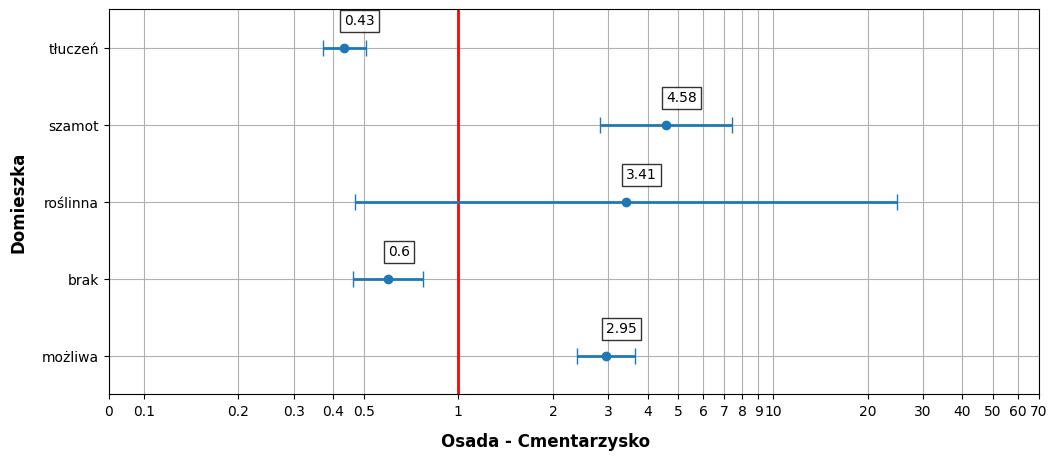

In [97]:
wykres(dom_prop, (12, 5), 0.3, 0.47, (0.5, 5.5), 'Domieszka')

In [98]:
cem_for_pca = cemetery_raw[['możliwa', 'brak', 'piasek', 'roślinna', 'szamot', 'tłuczeń', 'Grupa techn.']].groupby('Grupa techn.').sum()
cem_for_pca.insert(0, 'site', ['1' for i in range(len(cem_for_pca.index))])

In [99]:
range(len(settlement_raw.index.to_list()))

range(0, 2177)

In [100]:
set_for_pca = settlement_raw[['możliwa', 'brak', 'piasek', 'roślinna', 'szamot', 'tłuczeń', 'Grupa techn.']].groupby('Grupa techn.').sum()
set_for_pca.insert(0, 'site', ['2' for i in range(len(set_for_pca.index))])

In [101]:
data_for_pca = pd.concat([pd.concat([set_for_pca['site'], cem_for_pca['site']]), pd.concat([percentage(set_for_pca.loc[:, set_for_pca.columns != 'site'].astype(float).T).T, percentage(cem_for_pca.loc[:, cem_for_pca.columns != 'site'].astype(float).T).T])], axis=1)
data_for_pca.columns = ['site', 'możliwa', 'brak', 'piasek', 'roślinna', 'szamot', 'tłuczeń']
data_for_pca
# percentage(data_for_pca.astype(float))
# d = data_for_pca.astype(float)
# percentage(d)
data_for_pca

,site,możliwa,brak,piasek,roślinna,szamot,tłuczeń
1,2,7.692308,11.538462,0.0,0.000000,0.000000,80.769231
2a,2,12.371134,7.216495,0.0,0.000000,0.000000,80.412371
2b,2,0.000000,0.000000,0.0,0.000000,4.225352,95.774648
3a,2,17.380952,13.809524,0.0,0.238095,1.428571,67.142857
3b,2,0.140252,0.000000,0.0,0.000000,1.122020,98.737728
3c,2,0.129702,0.000000,0.0,0.000000,0.000000,99.870298
4,2,16.666667,8.333333,0.0,0.000000,0.000000,75.000000
1,1,0.000000,0.000000,0.0,0.000000,0.000000,100.000000
2a,1,3.259005,0.171527,0.0,0.000000,0.000000,96.569468
3a,1,18.362667,3.111056,0.0,0.254090,4.040654,74.231532


In [102]:
standardised_dom = scale(data_for_pca.loc[:, data_for_pca.columns != 'site'])
standardised_dom = pd.DataFrame(standardised_dom, index=data_for_pca.index, columns=data_for_pca.loc[:, data_for_pca.columns != 'site'].columns)
standardised_dom.fillna(0, inplace=True)

In [103]:
dom_pca = PCA()
dom_pca.fit(standardised_dom)
dom_pca_data = dom_pca.transform(standardised_dom)

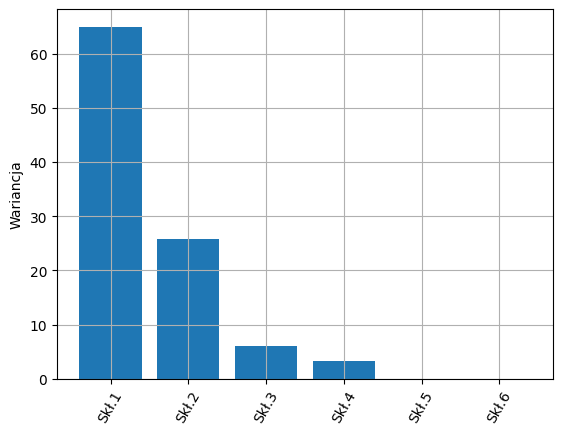

In [104]:
expl_var = dom_pca.explained_variance_ratio_*100
labels = ["Skł."+str(i) for i in range(1, len(expl_var)+1)]

plt.bar(range(1, len(expl_var)+1), expl_var)
plt.xticks(range(1, len(expl_var)+1), labels, rotation=60)
plt.ylabel("Wariancja")
plt.grid(True, which='both')
plt.show()

In [105]:
def pca_scatter(pca, concatenated, pca_data, standardised_values, features, classifs, v1, v2):
    foo = pca_data
    bar = pd.DataFrame(zip(foo[:, v1-1], foo[:, v2-1], classifs, concatenated['site']), columns=[f"PC{v1}", f"PC{v2}", "Class", 'site'])
    # bar = pd.DataFrame(zip(foo[:, v1-1], foo[:, v2-1], classifs), columns=[f"PC{v1}", f"PC{v2}", "Class"])
    fig, ax = plt.subplots(figsize=(5, 5))
    plt.grid(True, which='both')
    colors = {
        '1': '#1f77b4',
        '2a': '#ff7f0e',
        '2b': '#2ca02c',
        '3a': '#d62728',
        '3b': '#9467bd',
        '3c': '#8c564b',
        '4': '#e377c2'
    }
    for i in bar.index.to_list():
      if bar['site'].loc[i] == '1':
        ax.scatter(bar[bar.columns[0]].loc[i], bar[bar.columns[1]].loc[i], s=80.0, marker='D', c=colors[bar['Class'].loc[i]], zorder=2, alpha=0.75, edgecolors='k')
      else:
        ax.scatter(bar[bar.columns[0]].loc[i], bar[bar.columns[1]].loc[i], s=80.0, marker='o', c=colors[bar['Class'].loc[i]], zorder=2, alpha=0.75, edgecolors='k')

      # ax.scatter(bar[bar.columns[0]].loc[i], bar[bar.columns[1]].loc[i], s=80.0, marker='o', c=colors[bar['Class'].loc[i]], zorder=2, alpha=0.75, edgecolors='k')
# ================================================================
    # explained_variances = pca.explained_variance_ratio_
    # loadings = pca.components_.T * np.sqrt(explained_variances)
    # for i, feature in enumerate(standardised_values.columns):

    #   # Add the name of the variable near the arrow
    #   if loadings[i, 0]>0:
    #     plt.annotate(feature, (loadings[i, 0]+1, loadings[i, 1]*2.5), color='black', bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))
    #   else:
    #     plt.annotate(feature, (loadings[i, 0]-1, loadings[i, 1]*3), color='black', bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))

    #   # Add an arrow representing the variable on the new axis
    #   plt.arrow(0, 0,
    #             loadings[i, 0],
    #             loadings[i, 1],
    #             color='black',
    #             alpha=1.0,
    #             width=0.01,
    #           )
# ==================================================================
    legend1 = ax.legend(colors, loc="center", title="Grupa techn.")
    ax.add_artist(legend1)
    cem_line = mlines.Line2D([], [], color='k', marker='D', markersize=7.5, markerfacecolor='w', label='Cmentarzysko', linewidth=0)
    set_line = mlines.Line2D([], [], color='k', marker='o', markersize=7.5, markerfacecolor='w', label='Osada', linewidth=0)
    legend2 = ax.legend(handles=[cem_line, set_line], loc="upper center", title="Stanowisko")
    # sns.lmplot(bar, x=f"PC{v1}", y=f"PC{v2}", hue="Class", fit_reg=False, height=6, markers='P')
    # for x, y, s in zip(foo[:, v1-1], foo[:, v2-1], concatenated['site']):
    #   if s == '1':
    #     plt.text(x = x+.1, y = y+.1, s = s, color='black')
    #   else:
    #     plt.text(x = x-.1, y = y+.1, s = s, color='black')
    plt.xlabel(f"PC{v1}")
    plt.ylabel(f"PC{v2}")


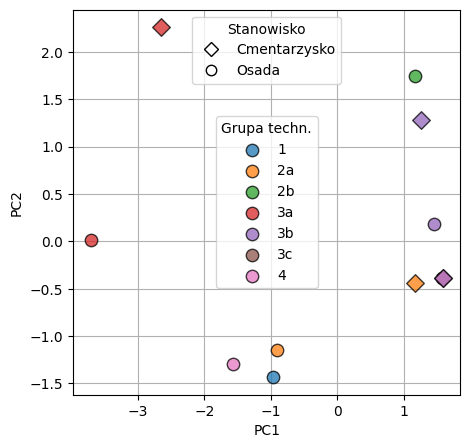

In [106]:
pca_scatter(dom_pca, data_for_pca, dom_pca_data, standardised_dom, standardised_dom.columns.to_list(), standardised_dom.index, v1=1, v2=2)

In [107]:
pd.DataFrame(dom_pca.components_.T * np.sqrt(dom_pca.explained_variance_ratio_), index=standardised_dom.columns, columns=["Skł."+str(i) for i in range(1, len(expl_var)+1)])

,Skł.1,Skł.2,Skł.3,Skł.4,Skł.5,Skł.6
możliwa,-0.429220,-0.029022,1.963170e-02,0.120593,1.012425e-16,1.584086e-18
brak,-0.377373,-0.189084,-1.022709e-01,-0.106665,6.746188e-17,1.055539e-18
piasek,0.000000,-0.000000,2.720027e-17,-0.000000,-1.379039e-17,4.649495e-17
roślinna,-0.350798,0.206408,1.712719e-01,-0.070729,1.254181e-18,1.962349e-20
szamot,-0.066599,0.421889,-1.325501e-01,-0.002182,2.224108e-17,3.479941e-19
tłuczeń,0.442009,0.037765,4.770528e-02,-0.030427,1.602563e-16,2.507444e-18


In [108]:
settlement_raw.groupby(['Grupa techn.', 'Domieszka']).count()

site  Jama  Barwa zewn.  Barwa wewn.  Faktura  \
Grupa techn. Domieszka                                                  
1            0             3     3            3            3        3   
             0/k           2     2            2            2        2   
             k            21    21           21           21       21   
2a           0             7     7            7            7        7   
             0/k          12    12           12           12       12   
             k            78    78           78           78       78   
2b           k            65    65           65           65       65   
             k+s           3     3            3            3        3   
3a           0            58    58           58           58       58   
             0/k          73    73           73           73       73   
             k           276   276          276          276      276   
             k+s           3     3            3            3        3   
             k, s?         1     1            1            1        1   
             k/s           2     2            2            2        2   
             roślinna?     1     1            1            1        1   
3b           0/k           1     1            1            1        1   
             k           695   695          695          695      695   
             k             1     1            1            1        1   
             k+s           8     8            8            8        8   
3c           0/k           1     1            1            0        1   
             k           770   770          156            1      153   
4            0             1     1            1            1        1   
             0/k           2     2            2            2        2   
             k             9     9            9            9        9   

                        możliwa  brak  piasek  roślinna  szamot  ...  \
Grupa techn. Domieszka                                           ...   
1            0                3     3       3         3       3  ...   
             0/k              2     2       2         2       2  ...   
             k               21    21      21        21      21  ...   
2a           0                7     7       7         7       7  ...   
             0/k             12    12      12        12      12  ...   
             k               78    78      78        78      78  ...   
2b           k               65    65      65        65      65  ...   
             k+s              3     3       3         3       3  ...   
3a           0               58    58      58        58      58  ...   
             0/k             73    73      73        73      73  ...   
             k              276   276     276       276     276  ...   
             k+s              3     3       3         3       3  ...   
             k, s?            1     1       1         1       1  ...   
             k/s              2     2       2         2       2  ...   
             roślinna?        1     1       1         1       1  ...   
3b           0/k              1     1       1         1       1  ...   
             k              695   695     695       695     695  ...   
             k                1     1       1         1       1  ...   
             k+s              8     8       8         8       8  ...   
3c           0/k              1     1       1         1       1  ...   
             k              770   770     770       770     770  ...   
4            0                1     1       1         1       1  ...   
             0/k              2     2       2         2       2  ...   
             k                9     9       9         9       9  ...   

                        dołki paznokciowe  otwory pod wylewem  dołki palcowe  \
Grupa techn. Domieszka                                                         
1            0                          0                   0              0   
            

In [109]:
cemetery_raw.groupby(['Grupa techn.', 'Domieszka']).count()

Grób  Barwa zewn.  Barwa wewn.  Faktura  możliwa  \
Grupa techn. Domieszka                                                        
1            k                6            6            6        6        6   
2a           0                1            1            1        1        1   
             0/k              1            1            1        1        1   
             k               10           10           10       10       10   
3a           0               25           25           25       25       25   
             0/k             78           78           78       78       78   
             0/k/p            1            1            1        1        1   
             0/k/p?           1            1            1        1        1   
             0/k/s?           2            2            2        2        2   
             g                1            1            1        1        1   
             k              204          204          204      204      204   
             k(s?)            1            1            1        1        1   
             k, s             4            4            4        4        4   
             k, s?            2            2            2        2        2   
             k, s?, roĹ›l     1            1            1        1        1   
             k/s?             1            1            1        1        1   
             k/s?/r?          1            1            1        1        1   
             s                1            1            1        1        1   
3b           k               89           89           89       89       89   
             k, s             3            3            3        3        3   
             k, s?            1            1            1        1        1   
4            k                2            2            2        2        2   

                           brak  piasek  roślinna  szamot  tłuczeń  ...  \
Grupa techn. Domieszka                                              ...   
1            k                6       6         6       6        6  ...   
2a           0                1       1         1       1        1  ...   
             0/k              1       1         1       1        1  ...   
             k               10      10        10      10       10  ...   
3a           0               25      25        25      25       25  ...   
             0/k             78      78        78      78       78  ...   
             0/k/p            1       1         1       1        1  ...   
             0/k/p?           1       1         1       1        1  ...   
             0/k/s?           2       2         2       2        2  ...   
             g                1       1         1       1        1  ...   
             k              204     204       204     204      204  ...   
             k(s?)            1       1         1       1        1  ...   
             k, s             4       4         4       4        4  ...   
             k, s?            2       2         2       2        2  ...   
             k, s?, roĹ›l     1       1         1       1        1  ...   
             k/s?             1       1         1       1        1  ...   
             k/s?/r?          1       1         1       1        1  ...   
             s                1       1         1       1        1  ...   
3b           k               89      89        89      89       89  ...   
             k, s             3       3         3       3        3  ...   
             k, s?            1       1         1       1        1  ...   
4            k                2       2         2       2        2  ...   

                           dołki paznokciowe  otwory pod wylewem  \
Grupa techn. Domieszka                                             
1            k                             0                   1   
2a           0                             0                   1   
             0/k                           0             

In [110]:
domieszka(cemetery_raw)

In [111]:
domieszka(settlement_raw)

In [112]:
cem_dom_mass = cemetery_raw.groupby(['Grupa techn.', 'Domieszka']).agg({'Ilość skorup': 'sum', 'Masa [g]': 'sum'})
cem_dom_mass

Ilość skorup  \
Grupa techn. Domieszka                                                   
1            tłuczeń kamienny                                      703   
2a           brak widocznej dom.                                     1   
             tłuczeń kam./ brak                                     19   
             tłuczeń kamienny                                      563   
3a           brak widocznej dom.                                   502   
             szamot                                                 36   
             tłuczeń kam., dom. roślinna, możliwy szamot            40   
             tłuczeń kam., możliwy szamot                          181   
             tłuczeń kam., piasek/ brak                             86   
             tłuczeń kam., szamot                                  321   
             tłuczeń kam., szamot/ brak                             37   
             tłuczeń kam./ brak                                   2916   
             tłuczeń kam./ szamot                                   73   
             tłuczeń kam./ szamot/ dom. roślinna                     1   
             tłuczeń kamienny                                    11362   
3b           tłuczeń kam., możliwy szamot                           75   
             tłuczeń kam., szamot                                  184   
             tłuczeń kamienny                                     7320   
4            tłuczeń kamienny                                      116   

                                                         Masa [g]  
Grupa techn. Domieszka                                             
1            tłuczeń kamienny                               15182  
2a           brak widocznej dom.                             1970  
             tłuczeń kam./ brak                              1191  
             tłuczeń kamienny                               13067  
3a           brak widocznej dom.                             7520  
             szamot                                          1708  
             tłuczeń kam., dom. roślinna, możliwy szamot     2365  
             tłuczeń kam., możliwy szamot                    2888  
             tłuczeń kam., piasek/ brak                      2929  
             tłuczeń kam., szamot                            7559  
             tłuczeń kam., szamot/ brak                      2632  
             tłuczeń kam./ brak                             93639  
             tłuczeń kam./ szamot                            3037  
             tłuczeń kam./ szamot/ dom. roślinna               91  
             tłuczeń kamienny                              280994  
3b           tłuczeń kam., możliwy szamot                    2437  
             tłuczeń kam., szamot                            7869  
             tłuczeń kamienny                              150779  
4            tłuczeń kamienny                                1873

In [113]:
cem_dom = cemetery_raw.groupby(['Grupa techn.', 'Domieszka']).agg({'Masa [g]': 'sum'})
cem_dom

Masa [g]
Grupa techn. Domieszka                                           
1            tłuczeń kamienny                               15182
2a           brak widocznej dom.                             1970
             tłuczeń kam./ brak                              1191
             tłuczeń kamienny                               13067
3a           brak widocznej dom.                             7520
             szamot                                          1708
             tłuczeń kam., dom. roślinna, możliwy szamot     2365
             tłuczeń kam., możliwy szamot                    2888
             tłuczeń kam., piasek/ brak                      2929
             tłuczeń kam., szamot                            7559
             tłuczeń kam., szamot/ brak                      2632
             tłuczeń kam./ brak                             93639
             tłuczeń kam./ szamot                            3037
             tłuczeń kam./ szamot/ dom. roślinna               91
             tłuczeń kamienny                              280994
3b           tłuczeń kam., możliwy szamot                    2437
             tłuczeń kam., szamot                            7869
             tłuczeń kamienny                              150779
4            tłuczeń kamienny                                1873

In [114]:
set_dom = settlement_raw.groupby(['Grupa techn.', 'Domieszka']).agg({'Jama': 'count'})
set_dom

Jama
Grupa techn. Domieszka                         
1            brak widocznej dom.              3
             tłuczeń kam./ brak               2
             tłuczeń kamienny                21
2a           brak widocznej dom.              7
             tłuczeń kam./ brak              12
             tłuczeń kamienny                78
2b           tłuczeń kam., szamot             3
             tłuczeń kamienny                65
3a           brak widocznej dom.             58
             możliwa dom. roślinna            1
             tłuczeń kam., możliwy szamot     1
             tłuczeń kam., szamot             3
             tłuczeń kam./ brak              73
             tłuczeń kam./ szamot             2
             tłuczeń kamienny               276
3b           tłuczeń kam., szamot             8
             tłuczeń kam./ brak               1
             tłuczeń kamienny               696
3c           tłuczeń kam./ brak               1
             tłuczeń kamienny               770
4            brak widocznej dom.              1
             tłuczeń kam./ brak               2
             tłuczeń kamienny                 9

In [115]:
# cem_dom.index.get_level_values(1)
# cem_dom.pivot(columns=cem_dom.index.get_level_values(1), index=cem_dom.index.get_level_values(0), values=cem_dom['Grób'])
dom_wykr_cem = cem_dom.unstack().T.reset_index(level=0, inplace=False, drop=True).sort_values(by='3a', ascending=False)
# dom_wykr_cem.fillna(0, inplace=True)
# dom_wykr_cem

In [116]:
dom_wykr_cem['suma'] = [dom_wykr_cem.T[col].sum() for col in dom_wykr_cem.T.columns]
dom_wykr_cem

Grupa techn.,1,2a,3a,3b,4,suma
Domieszka,,,,,,
tłuczeń kamienny,15182,13067,280994,150779,1873,461895
tłuczeń kam./ brak,NaN,1191,93639,NaN,NaN,94830
"tłuczeń kam., szamot",NaN,NaN,7559,7869,NaN,15428
brak widocznej dom.,NaN,1970,7520,NaN,NaN,9490
tłuczeń kam./ szamot,NaN,NaN,3037,NaN,NaN,3037
"tłuczeń kam., piasek/ brak",NaN,NaN,2929,NaN,NaN,2929
"tłuczeń kam., możliwy szamot",NaN,NaN,2888,2437,NaN,5325
"tłuczeń kam., szamot/ brak",NaN,NaN,2632,NaN,NaN,2632
"tłuczeń kam., dom. roślinna, możliwy szamot",NaN,NaN,2365,NaN,NaN,2365


In [117]:
dom_wykr_set = set_dom.unstack().T.reset_index(level=0, inplace=False, drop=True).sort_values(by='3a', ascending=False)
# dom_wykr_set.fillna(0, inplace=True)

In [118]:
dom_wykr_set['suma'] = [dom_wykr_set.T[col].sum() for col in dom_wykr_set.T.columns]
dom_wykr_set

Grupa techn.,1,2a,2b,3a,3b,3c,4,suma
Domieszka,,,,,,,,
tłuczeń kamienny,21.0,78.0,65.0,276.0,696.0,770.0,9.0,1915.0
tłuczeń kam./ brak,2.0,12.0,NaN,73.0,1.0,1.0,2.0,91.0
brak widocznej dom.,3.0,7.0,NaN,58.0,NaN,NaN,1.0,69.0
"tłuczeń kam., szamot",NaN,NaN,3.0,3.0,8.0,NaN,NaN,14.0
tłuczeń kam./ szamot,NaN,NaN,NaN,2.0,NaN,NaN,NaN,2.0
możliwa dom. roślinna,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0
"tłuczeń kam., możliwy szamot",NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0


{'tłuczeń kamienny': '#1f77b4', 'tłuczeń kam./ brak': '#ff7f0e', 'brak widocznej dom.': '#2ca02c'}


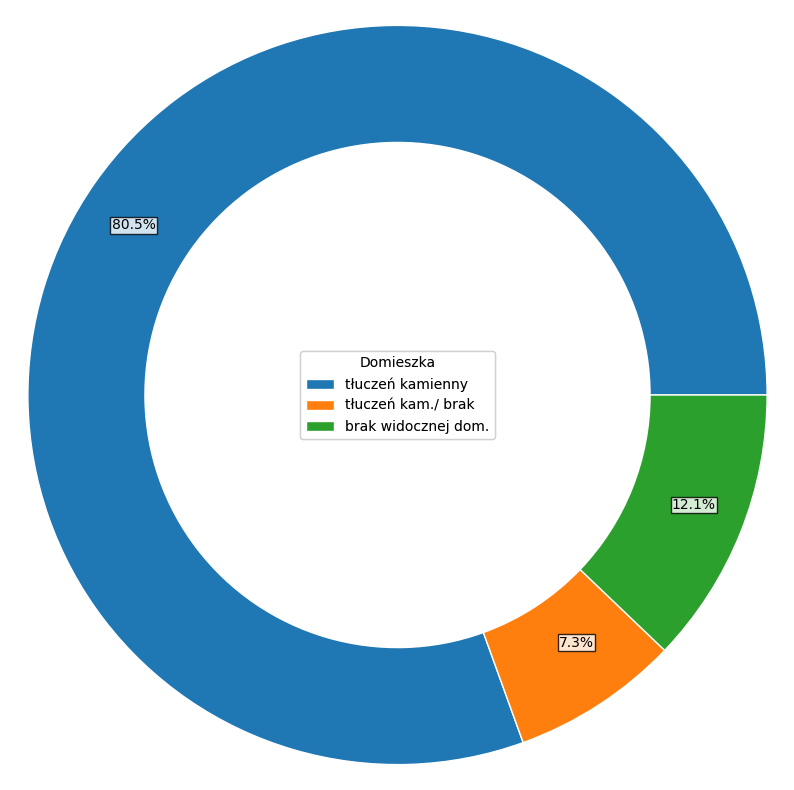

In [119]:
series = dom_wykr_cem['2a'].dropna(inplace=False)
# series = pd.concat([dom_wykr_cem['3a'][:4], pd.Series(dom_wykr_cem['3a'][-7:].sum(), index=['inna'])])


fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('equal')
palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#7E8E94", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#f1c40f", "#e67e22"
]
chart_colors = {item:palette[series.index.to_list().index(item)] for item in series.index.to_list()}
print(chart_colors)
# Outer pie
wedges, texts = ax.pie(
    series,
    radius=1.2,
    labels=[f'{item:.1f}%' for item in percent(series)],
    labeldistance=0.8,
    colors=palette,
    wedgeprops=dict(width=0.38, edgecolor='w'),
    textprops=dict(bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))
)

legend1 = ax.legend(chart_colors, loc="center", title="Domieszka")
ax.add_artist(legend1)
plt.show()

{'tłuczeń kamienny': '#1f77b4', 'tłuczeń kam./ brak': '#ff7f0e', 'brak widocznej dom.': '#2ca02c', 'inna': '#7E8E94'}


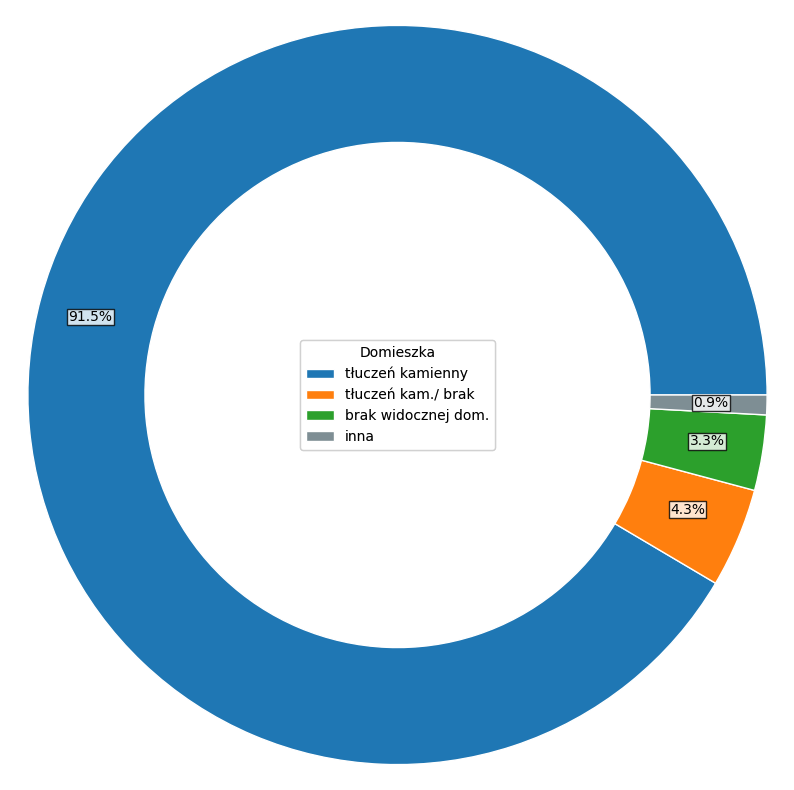

In [120]:
# series = dom_wykr_set['suma']
series = pd.concat([dom_wykr_set['suma'][:3], pd.Series(dom_wykr_set['suma'][-4:].sum(), index=['inna'])])


fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('equal')
palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c",
    "#7E8E94", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#f1c40f", "#e67e22"
]
chart_colors = {item:palette[series.index.to_list().index(item)] for item in series.index.to_list()}
print(chart_colors)
# Outer pie
wedges, texts = ax.pie(
    series,
    radius=1.2,
    labels=[f'{item:.1f}%' for item in percent(series)],
    labeldistance=0.8,
    colors=palette,
    wedgeprops=dict(width=0.38, edgecolor='w'),
    textprops=dict(bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))
)

legend1 = ax.legend(chart_colors, loc="center", title="Domieszka")
ax.add_artist(legend1)
plt.show()

{'tłuczeń kamienny': '#1f77b4', 'tłuczeń kam./ brak': '#ff7f0e', 'tłuczeń kam., szamot': '#2ca02c', 'brak widocznej dom.': '#d62728', 'tłuczeń kam./ szamot': '#9467bd', 'inna': '#7E8E94'}


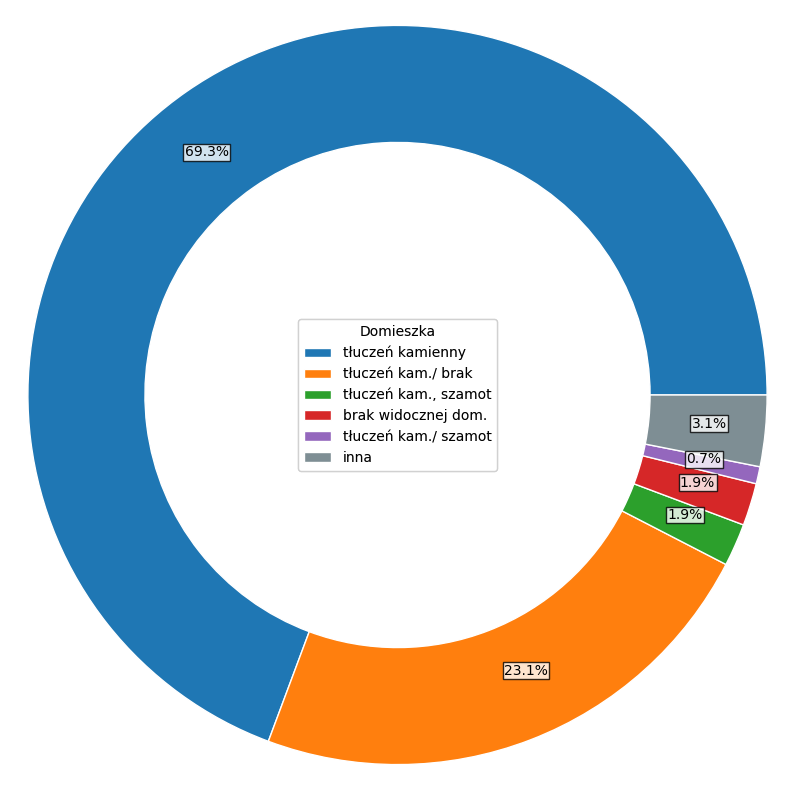

In [121]:
# print(dom_wykr_cem['3a'][-6:])
series = pd.concat([dom_wykr_cem['3a'][:5], pd.Series(dom_wykr_cem['3a'][-6:].sum(), index=['inna'])])


fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('equal')
palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#7E8E94", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#f1c40f", "#e67e22"
]
chart_colors = {item:palette[series.index.to_list().index(item)] for item in series.index.to_list()}
print(chart_colors)
# Outer pie
wedges, texts = ax.pie(
    series,
    radius=1.2,
    labels=[f'{item:.1f}%' for item in percent(series)],
    labeldistance=0.8,
    colors=palette,
    wedgeprops=dict(width=0.38, edgecolor='w'),
    textprops=dict(bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))
)

legend1 = ax.legend(chart_colors, loc="center", title="Domieszka")
ax.add_artist(legend1)
plt.show()

{'tłuczeń kamienny': '#1f77b4', 'tłuczeń kam., szamot': '#ff7f0e', 'tłuczeń kam., możliwy szamot': '#2ca02c'}


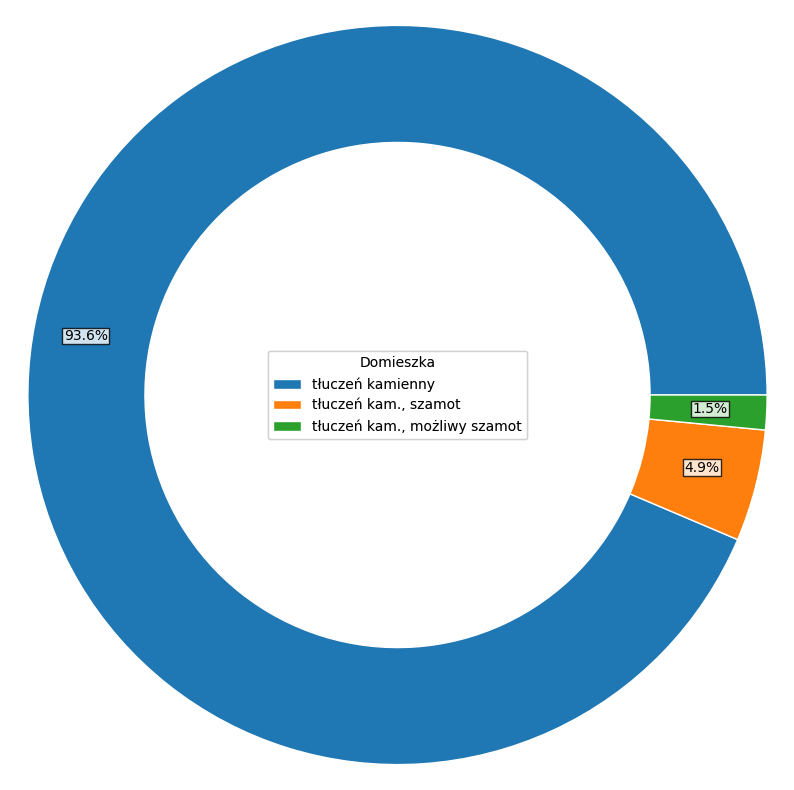

In [122]:
series = dom_wykr_cem['3b']
series.dropna(inplace=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('equal')
palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#f1c40f", "#e67e22"
]
chart_colors = {item:palette[series.index.to_list().index(item)] for item in series.index.to_list()}
print(chart_colors)
# Outer pie
wedges, texts = ax.pie(
    series,
    radius=1.2,
    labels=[f'{item:.1f}%' for item in percent(series)],
    labeldistance=0.8,
    colors=palette,
    wedgeprops=dict(width=0.38, edgecolor='w'),
    textprops=dict(bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))
)

legend1 = ax.legend(chart_colors, loc="center", title="Domieszka")
ax.add_artist(legend1)
plt.show()

{'tłuczeń kamienny': '#1f77b4', 'tłuczeń kam./ brak': '#ff7f0e', 'tłuczeń kam., szamot': '#2ca02c'}


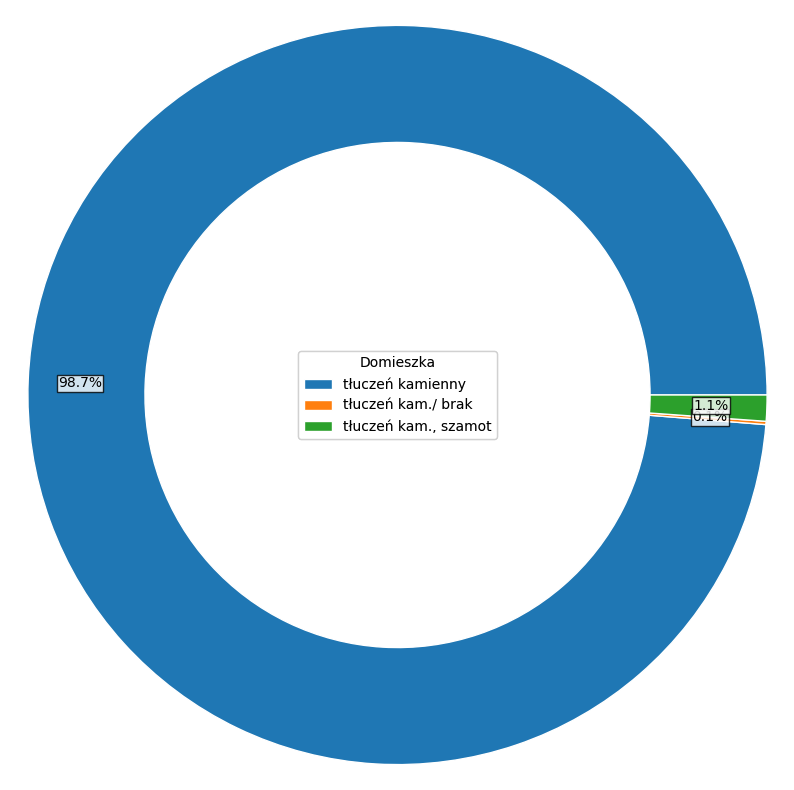

In [123]:
series = dom_wykr_set['3b']
series.dropna(inplace=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('equal')
palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#f1c40f", "#e67e22"
]
chart_colors = {item:palette[series.index.to_list().index(item)] for item in series.index.to_list()}
print(chart_colors)
# Outer pie
wedges, texts = ax.pie(
    series,
    radius=1.2,
    labels=[f'{item:.1f}%' for item in percent(series)],
    labeldistance=0.8,
    colors=palette,
    wedgeprops=dict(width=0.38, edgecolor='w'),
    textprops=dict(bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))
)

legend1 = ax.legend(chart_colors, loc="center", title="Domieszka")
ax.add_artist(legend1)
plt.show()

{'tłuczeń kamienny': '#1f77b4', 'tłuczeń kam./ brak': '#ff7f0e', 'brak widocznej dom.': '#2ca02c', 'tłuczeń kam., szamot': '#d62728', 'inna': '#7E8E94'}


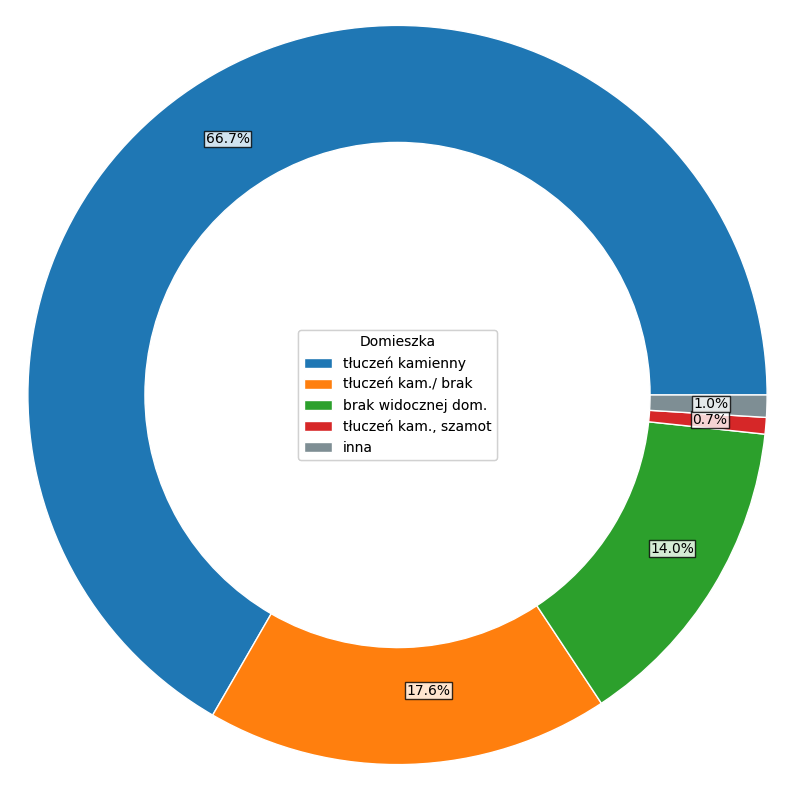

In [124]:
series = pd.concat([dom_wykr_set['3a'][:4], pd.Series(dom_wykr_set['3a'][-3:].sum(), index=['inna'])])


fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('equal')
palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#7E8E94", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#f1c40f", "#e67e22"
]
chart_colors = {item:palette[series.index.to_list().index(item)] for item in series.index.to_list()}
print(chart_colors)
# Outer pie
wedges, texts = ax.pie(
    series,
    radius=1.2,
    labels=[f'{item:.1f}%' for item in percent(series)],
    labeldistance=0.8,
    colors=palette,
    wedgeprops=dict(width=0.38, edgecolor='w'),
    textprops=dict(bbox = dict(boxstyle="Square, pad=0.1", facecolor = 'white', alpha = .8))
)

legend1 = ax.legend(chart_colors, loc="center", title="Domieszka")
ax.add_artist(legend1)
plt.show()